# Read output files from Delft3D and compare with measurements

NETCDF format output

Author: Sofia Midauar

Date: May 2024

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import glob2 as glob
import platform
import os
import sys
import seaborn as sns
import re
from matplotlib import dates as mpl_dates
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import calendar
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime, timedelta
from datetime import date, timedelta

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Functions

In [4]:
# Define function to estimate depth from layer
def layer_thickness(layer):
    """returns the corresponding layer thickness given the maximum depth at the analysed timestep"""
    max_depth = 14.79
    if layer == 0:
        return (0.125 * max_depth)
    if layer == 1:
        return (0.0625 * max_depth)
    if layer == 2:
        return (0.0625 * max_depth)
    if layer == 3:
        return (0.0625 * max_depth)
    if layer == 4:
        return (0.0625 * max_depth)
    if layer == 5: 
        return (0.0625 * max_depth)
    if layer == 6:
        return (0.0625 * max_depth)
    if layer == 7:
        return (0.0625 * max_depth)
    if layer == 8:
        return (0.03125 * max_depth)
    if layer == 9:
        return (0.03125 * max_depth)
    if layer == 10:
        return (0.03125 * max_depth)
    if layer == 11:
        return (0.03125 * max_depth)
    if layer == 12:
        return (0.03125 * max_depth)
    if layer == 13:
        return (0.03125 * max_depth)
    if layer == 14:
        return (0.125 * max_depth)
    if layer == 15:
        return (0.125 * max_depth)

# Read MONTHLY measurements - locations CAB01 and BIS

First sheets - WT, Sat-O2, DO, pH

In [5]:
## Read data transforming date and time separate columns into a combined column
# Cab 01
monthly_data_CAB01 = pd.read_excel('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_monthly_monitoring_complete.xlsx', 
                             sheet_name = "CAB_Env", parse_dates = [['Date', 'Heure']], date_format = "YYYY-MM-DD HH:MM:SS")

monthly_data_CAB01[['day','hour']] = monthly_data_CAB01['Date_Heure'].str.split(' ', expand = True)[[0,2]]
monthly_data_CAB01['time'] = monthly_data_CAB01[['day','hour']].apply(' '.join, axis=1)

monthly_data_CAB01['time'] = pd.to_datetime(monthly_data_CAB01['time'], format = '%Y-%m-%d %H:%M:%S')
monthly_data_CAB01.set_index('time', inplace = True)
monthly_data_CAB01 = monthly_data_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00'] # calibration period
monthly_data_CAB01.drop(['Date_Heure','day', 'hour'], axis = 1, inplace = True)

# BIS
monthly_data_BIS = pd.read_excel('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_monthly_monitoring_complete.xlsx', 
                             sheet_name = "CAB_BIS_env", parse_dates = [['Date', 'Hour']], date_format = "YYYY-MM-DD HH:MM:SS")
monthly_data_BIS[['day','hour']] = monthly_data_BIS['Date_Hour'].str.split(' ', expand = True)[[0,2]]
monthly_data_BIS['time'] = monthly_data_BIS[['day','hour']].apply(' '.join, axis=1)

monthly_data_BIS['time'] = pd.to_datetime(monthly_data_BIS['time'], format = '%Y-%m-%d %H:%M:%S')
monthly_data_BIS.set_index('time', inplace = True)
monthly_data_BIS = monthly_data_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00'] # calibration period
monthly_data_BIS.drop(['Date_Hour','day', 'hour'], axis = 1, inplace = True)
monthly_data_BIS.head(2)

,Serie_ID,Site,max depth (m),Secchi (cm),Depth (m),Temperature (°C),Sat O2 (%),Con O2 (mg/L),Cond (µS/cm²),pH,Turbi (NTU)
time,,,,,,,,,,,
2022-12-12 13:50:00,1222,CAB_BIS,7.5,138,0.0,8.5,94.6,11.05,203.1,8.05,7.0
2022-12-12 13:50:00,1222,CAB_BIS,7.5,138,1.0,8.5,94.5,11.03,203.1,8.04,7.1


PAR

In [6]:
## PAR data 
# Read data transforming date and time separate columns into a combined column
monthly_PAR_BIS = pd.read_excel('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_data_2024/CAB_monthly_monitoring_complete.xlsx', 
                                 sheet_name = "PAR", parse_dates = [['Date', 'Heure']], date_format = 'YYYY-MM-DD HH:MM:SS')
monthly_PAR_BIS.dropna(inplace = True)

# last calibration step: '2023-06-13 12:45:00'
monthly_PAR_BIS[['day','hour']] = monthly_PAR_BIS['Date_Heure'].str.split(' ', expand = True)[[0,2]]
monthly_PAR_BIS['time'] = monthly_PAR_BIS[['day','hour']].apply(' '.join, axis=1)

monthly_PAR_BIS['time'] = pd.to_datetime(monthly_PAR_BIS['time'], format = '%Y-%m-%d %H:%M:%S')
monthly_PAR_BIS.set_index('time', inplace = True)
monthly_PAR_BIS = monthly_PAR_BIS.loc['2022-09-12 13:04:00':'2023-06-13 12:45:00'] # calibration period
monthly_PAR_BIS.drop(['Date_Heure','day', 'hour'], axis = 1, inplace = True)
monthly_PAR_BIS.head(2)

,Serie_id,Site,Prof PAR,PAR
time,,,,
2022-09-12 13:04:00,922,CAB,0.0,650.0
2022-09-12 13:04:00,922,CAB,0.2,437.0


Depth and Secchi depth + profiles

In [7]:
## Creates df with only profile measurements
# Cab 01
monthly_profiles_CAB01 = monthly_data_CAB01[monthly_data_CAB01.columns[4:]]
# monthly_profiles_CAB01.head(2)

# BIS
monthly_profiles_BIS = monthly_data_BIS[monthly_data_BIS.columns[4:]]
# monthly_profiles_BIS.head(2)

Depth and Secchi depth

In [8]:
## CAB01
# Create time series from measurements
reduced_CAB01 = monthly_data_CAB01.groupby('time').agg(list)
depth_CAB01 = pd.DataFrame(reduced_CAB01['max depth (m)'].to_list(), index = reduced_CAB01.index)
depth_CAB01.sort_index(inplace = True)
depth_CAB01 = pd.DataFrame(depth_CAB01[depth_CAB01.columns[0]])
depth_CAB01.columns = ['depth_m']
depth_CAB01 = depth_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# depth_CAB01.head(2)

# Create Secchi depth time series from measurements
reduced_CAB01 = monthly_data_CAB01.groupby('time').agg(list)
Secchi_depth_CAB01 = pd.DataFrame(reduced_CAB01['Secchi (cm)'].to_list(), index = reduced_CAB01.index)
Secchi_depth_CAB01.sort_index(inplace = True)
Secchi_depth_CAB01 = pd.DataFrame(Secchi_depth_CAB01[Secchi_depth_CAB01.columns[0]])
Secchi_depth_CAB01.columns = ['Secchi_depth_cm']
Secchi_depth_CAB01['Secchi_depth_m'] = (Secchi_depth_CAB01['Secchi_depth_cm']/100)
Secchi_depth_CAB01 = Secchi_depth_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']

Secchi_depth_CAB01.head(2)

,Secchi_depth_cm,Secchi_depth_m
time,,
2022-09-12 13:04:00,176,1.76
2022-12-12 12:30:00,140,1.40


In [9]:
## BIS
# Create depth time series from measurements
reduced_BIS = monthly_data_BIS.groupby('time').agg(list)
depth_BIS = pd.DataFrame(reduced_BIS['max depth (m)'].to_list(), index = reduced_BIS.index)
depth_BIS.sort_index(inplace = True)
depth_BIS = pd.DataFrame(depth_BIS[depth_BIS.columns[0]])
depth_BIS.columns = ['depth_m']
depth_BIS = depth_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# depth_BIS.head(2)

# Create Secchi depth time series from measurements
reduced_BIS = monthly_data_BIS.groupby('time').agg(list)
Secchi_depth_BIS = pd.DataFrame(reduced_BIS['Secchi (cm)'].to_list(), index = reduced_BIS.index)
Secchi_depth_BIS.sort_index(inplace = True)
Secchi_depth_BIS = pd.DataFrame(Secchi_depth_BIS[Secchi_depth_BIS.columns[0]])
Secchi_depth_BIS.columns = ['Secchi_depth_cm']
Secchi_depth_BIS['Secchi_depth_m'] = (Secchi_depth_BIS['Secchi_depth_cm']/100)
Secchi_depth_BIS = Secchi_depth_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']

Secchi_depth_BIS.head(2)

,Secchi_depth_cm,Secchi_depth_m
time,,
2022-12-12 13:50:00,138,1.38
2023-03-16 13:30:00,210,2.10


Profiles - water temperature, oxygen saturation, DO, and pH

In [10]:
## Cab 01
# Creates dataframe with water temperature measurements
WT_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[0:2]]
WT_CAB01 = WT_CAB01[WT_CAB01['Temperature (°C)'] < 50] # removes outlier (measurement of 75ºC)
WT_CAB01.sort_index(inplace = True)
WT_CAB01 = WT_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# WT_CAB01.head(2)

# Creates dataframe with water sat_O2 measurements
sat_O2_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[[0,2]]]
sat_O2_CAB01.sort_index(inplace = True)
sat_O2_CAB01 = sat_O2_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# sat_O2_CAB01.head(2)

# Creates dataframe with water DO measurements
DO_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[[0,3]]]
DO_CAB01 = DO_CAB01[DO_CAB01['Con O2 (mg/L)'] < 50] # removes outlier (measurement of 70 and another of 1,000)
DO_CAB01.sort_index(inplace = True)
DO_CAB01 = DO_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# DO_CAB01.head(2)

# Creates dataframe with water DO measurements
pH_CAB01 = monthly_profiles_CAB01[monthly_profiles_CAB01.columns[[0,5]]]
pH_CAB01.sort_index(inplace = True)
pH_CAB01 = pH_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
pH_CAB01.head(2)

,Depth (m),pH
time,,
2022-09-12 13:04:00,0.0,7.8
2022-09-12 13:04:00,1.0,7.8


In [11]:
## BIS
# Creates dataframe with water temperature measurements
WT_BIS = monthly_profiles_BIS[monthly_profiles_BIS.columns[0:2]]
WT_BIS.sort_index(inplace = True)
WT_BIS = WT_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# WT_BIS.head(2)

# Creates dataframe with sat_O2 measurements
sat_O2_BIS = monthly_profiles_BIS[monthly_profiles_BIS.columns[[0,2]]]
sat_O2_BIS.sort_index(inplace = True)
sat_O2_BIS = sat_O2_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# sat_O2_BIS.head(2)

# Creates dataframe with water DO measurements
DO_CAB01 = monthly_profiles_BIS[monthly_profiles_BIS.columns[[0,3]]]
DO_CAB01.sort_index(inplace = True)
DO_CAB01 = DO_CAB01.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
# DO_CAB01.head(2)

# Creates dataframe with pH measurements
pH_BIS = monthly_profiles_BIS[monthly_profiles_BIS.columns[[0,5]]]
pH_BIS.sort_index(inplace = True)
pH_BIS = pH_BIS.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']
pH_BIS.head(2)

,Depth (m),pH
time,,
2022-12-12 13:50:00,0.0,8.05
2022-12-12 13:50:00,1.0,8.04


# CAB location - high-freq DO

In [12]:
# List files
folder_DO_cab = ('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_O2data')
files_DO = sorted(glob.glob(folder_DO_cab + '/*.txt', recursive = True))

# Read files
for file in range(0, len(files_DO), 1):
    DO_temp = pd.read_csv(files_DO[file], skiprows = [0,1,2,3,4,5,6], 
                          usecols = [2,4,5,6], names = ['date', 'temp_degC', 'DO_mgl', 'DO_sat_percentage'], encoding='latin-1')
    DO_temp = DO_temp.loc[2:]
    DO_temp['date'] = pd.to_datetime(DO_temp['date'], format = "mixed")
    DO_temp[['temp_degC', 'DO_mgl', 'DO_sat_percentage']] = DO_temp[['temp_degC',
                                                                     'DO_mgl', 'DO_sat_percentage']].apply(pd.to_numeric)
    if file == 0:
        data_DO_CAB = DO_temp
    else:
        data_DO_CAB = pd.concat([data_DO_CAB, DO_temp])

data_DO_CAB.head(3)

,date,temp_degC,DO_mgl,DO_sat_percentage
2,2021-06-14 14:10:00,26.897,9.031,113.130650
3,2021-06-14 14:20:00,25.511,9.414,115.003912
4,2021-06-14 14:30:00,25.283,9.493,115.485580


In [13]:
# Create column with approximate time
data_DO_CAB['hour'] = data_DO_CAB['date'].dt.strftime('%H').astype(int) # creates column with only hour
data_DO_CAB['minute'] = data_DO_CAB['date'].dt.strftime('%M').astype('float') # creates column with only minute

# Creates column with round data for minute: we want only multiples of 10
data_DO_CAB['round_min'] = np.where((data_DO_CAB['minute'] % 10) == 0, data_DO_CAB['minute'], 
                                    (data_DO_CAB['minute']/10).astype(int)*10)

# Puts minute column with 2 digits always - we want to join this with the hour info
a = ["%02d" % x for x in data_DO_CAB['round_min']]
data_DO_CAB['round_min'] = a

# Join hour and minute
data_DO_CAB['round_hours'] = (data_DO_CAB['hour'].astype(str) + ':' + data_DO_CAB['round_min'].astype(str))

# Creates another column with datetime following rounded minutes
data_DO_CAB['date_approximate'] = pd.to_datetime(data_DO_CAB['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                 data_DO_CAB['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')

# Excludes intermediate columns
data_DO_CAB.set_index('date_approximate', inplace = True)
data_DO_CAB = data_DO_CAB[data_DO_CAB.columns[[0,1,2,3]]]
data_DO_CAB = data_DO_CAB.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00']

data_DO_CAB.tail(3)

,date,temp_degC,DO_mgl,DO_sat_percentage
date_approximate,,,,
2023-06-08 17:40:00,2023-06-08 17:42:00,22.865,10.437,121.364165
2023-06-08 17:50:00,2023-06-08 17:52:00,22.848,10.415,121.069211
2023-06-08 18:00:00,2023-06-08 18:02:00,22.815,10.487,121.829696


In [14]:
# Creates date list at 10min interval - start and end dates according to measurements
from datetime import datetime, timedelta # need to call again for the code to work...

# data_DO_CAB = data_DO_CAB.loc['2022-09-09 00:00:00':]
start_date = data_DO_CAB.index[0] # Locates initial measurement
end_date = data_DO_CAB.index[-1] # Locates final measurement
timedelta = timedelta(minutes = 10) # Creates time interval - frequency of measurements

date_list = []
curr_date = start_date

while curr_date <= end_date:
    date_list.append(curr_date)
    curr_date = curr_date + timedelta

# Transforms list to dataframe
dates_complete_OD = pd.DataFrame(date_list)
dates_complete_OD.rename(columns = {dates_complete_OD.columns[0]:'dates_complete_OD'}, inplace = True)
dates_complete_OD = pd.DataFrame(dates_complete_OD['dates_complete_OD'].astype(str)) # transforms data to string to be able to join with other data
dates_complete_OD.set_index('dates_complete_OD', inplace = True)
dates_complete_OD.head(2)

""
dates_complete_OD
2022-09-09 00:00:00
2022-09-09 00:10:00


In [15]:
# Creates complete dataset of measurements + gaps for each depth - one dataframe per depth
List_DO = data_DO_CAB.columns[1:]
gaps_list_DO = []
Dictionary_DO = {}

for i in List_DO:
    Dictionary_DO[i] = pd.DataFrame()
    Dictionary_DO[i] = data_DO_CAB[[i]]
    Dictionary_DO[i] = Dictionary_DO[i].dropna()
    Dictionary_DO[i].reset_index(inplace = True)
    Dictionary_DO[i]['date_approximate'] = Dictionary_DO[i]['date_approximate'].astype(str)
    Dictionary_DO[i].set_index('date_approximate', inplace = True)
    Dictionary_DO[i] = dates_complete_OD.join(Dictionary_DO[i], how = "outer")

# print("Created multiple dataframes in a loop:\n", Dictionary)

# Counts gaps and lists them
print('Percentage of gaps - calibration period')
print(' ')

for i in List_DO:
  gaps_DO = Dictionary_DO[i][Dictionary_DO[i].columns[0]].isna().sum().sum()
  total_values_DO = Dictionary_DO[i].shape[0]
  gaps_list_DO.append((gaps_DO/total_values_DO)*100)
  print(i + ': ' + '%0.4f%%' %((gaps_DO/total_values_DO)*100))

Percentage of gaps - calibration period
 
temp_degC: 0.0195%
DO_mgl: 0.0195%
DO_sat_percentage: 0.0195%


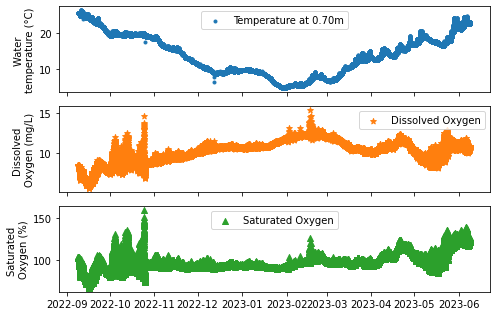

In [16]:
# Plot measurements from DO sonde 
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = [7,4.5], sharey = False, sharex = True)

legend = ['Temperature at 0.70m', 'Dissolved Oxygen', 'Saturated Oxygen']
markers = ['.', '*', '^']
pal = sns.color_palette("tab10", 10) # set colors (10 for 10 different colors)

# Create formatted date labels
# xlabels = ['Sep 22','Nov 22', 'Jan 23', 'Mar 23','May 23', 'Jul 23', 'Sep 23','Nov 23', 'Jan 24', 'Mar 24']
# xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]

for column in range(0, len(legend), 1):
    ax[column].scatter(data_DO_CAB.index, data_DO_CAB[data_DO_CAB.columns[column+1]], 
                       marker = markers[column], label = legend[column], color = pal.as_hex()[column])
    ax[column].legend()

# ax[2].set_xticklabels(xlabels_new)

ax[0].yaxis.set_label_text('Water \ntemperature (°C)', size = 10)
ax[1].yaxis.set_label_text('Dissolved \nOxygen (mg/L)', size = 10)
ax[2].yaxis.set_label_text('Saturated \nOxygen (%)', size = 10)

plt.subplots_adjust(left = None, bottom = None, right = None, top = None, wspace = None, hspace = None)
plt.tight_layout()

# Save graph
# plt.savefig('DO_CAB_sonde_measurements.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

# CAB location - high-freq - WT

In [17]:
## Routine to join multiple depths into one sheet
folder_cab = ('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_temperature_complete/CAB_01/')

# Import files from all field campaigns and join them into one dataframe
folders = sorted(glob.glob(folder_cab + '*/', recursive = True))
list_df_gaps_T = [] # creates empty list with dfs at every depth to count gaps!

# Routine for .txt data
for folder in range(0,5,1): # only the first 5 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'txt/*.txt')) # Create list with names of all files in the folder
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, delimiter = "\t", 
                            usecols = [0,1], names = ['date', 'temp_degC'], 
                            skiprows = [3,4,5]) # read files - space delimited, skips weird rows
    # do it for both temperature and lux columns - creates a list to be able to substitute comma by point
    txt = data_temp[data_temp.columns[1]]
    point_file = []
    for x in txt:
      x = re.sub(',', '.', x) # substitutes comma for point
      point_file.append(x) # makes a new list with point delimited numbers
    data_temp[data_temp.columns[1]] = point_file # substitutes comma delimited by point in the original dataframe
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], 
                                                    errors='coerce') # transform to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, 
                     inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%Y-%m-%d %H:%M:%S") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%y-%m-%d %H:%M:%S") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date','hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    # Join results
    if step == 0:
      measure_T = data_temp
    else:
      temp = data_temp
      measure_T = pd.merge(measure_T, temp, on = "date_approximate", how = "outer")
    # Creates a new list with dataframes for each depth to enable gap count
    df = pd.DataFrame.copy(data_temp)
    df['depth']=(str(folders[folder])[86:-1] + "_" + 
                 (os.path.basename(files[step]))) ## You can remove str() if everything in form is already a string
    list_df_gaps_T.append(df)
  if folder == 0:
    all_data_T = measure_T
  else:
    all_data_T = pd.concat([all_data_T, measure_T])

# Routine for .csv data
for folder in range(5,len(folders),1):
  # only the first 5 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'csv/*.csv'))
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, usecols = [1,2], 
                            names = ['date', 'temp_degC'], 
                            skiprows = [2,3,4]) # read files - space delimited, skips weird rows
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], 
                                                    errors='coerce') # transform to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, 
                     inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], 
                                         format = "%m/%d/%y %I:%M:%S %p") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], 
                                         format = "%m/%d/%y %H:%M") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date', 'hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    if step == 0:
      measure_T = data_temp
    else:
      measure_T = pd.merge(measure_T, data_temp, on = "date_approximate", how = "inner")
    df = pd.DataFrame.copy(data_temp) # Creates a new list with dataframes for each depth to enable gap count
    df['depth']=(str(folders[folder])[86:-1] + "_" + (os.path.basename(files[step]))) 
    list_df_gaps_T.append(df)
  all_data_T = pd.concat([all_data_T, measure_T])

all_data_T.set_index('date_approximate', inplace = True)
all_data_T = all_data_T.loc['2022-09-09 00:00:00':'2023-06-08 18:00:00'] # calibration period
all_data_T = all_data_T.reset_index()

all_data_T.head()

,date_approximate,T_CAB_0,T_CAB_1,T_CAB_2,T_CAB_3,T_CAB_4,T_CAB_5,T_CAB_7,T_CAB_8,T_CAB_9,T_CAB_6
0,2022-09-09 00:00:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,24.32,NaN
1,2022-09-09 00:10:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,24.36,NaN
2,2022-09-09 00:20:00,25.69,NaN,NaN,NaN,25.31,25.44,NaN,NaN,24.36,NaN
3,2022-09-09 00:30:00,25.69,NaN,NaN,NaN,25.31,25.39,NaN,NaN,24.36,NaN
4,2022-09-09 00:40:00,25.65,NaN,NaN,NaN,25.31,25.39,NaN,NaN,24.36,NaN


In [18]:
# Check if all the data is there
all_data_T.tail(5)

,date_approximate,T_CAB_0,T_CAB_1,T_CAB_2,T_CAB_3,T_CAB_4,T_CAB_5,T_CAB_7,T_CAB_8,T_CAB_9,T_CAB_6
36790,2023-06-08 17:20:00,23.484,23.196,23.196,23.196,23.196,23.100,18.901,18.711,17.855,19.662
36791,2023-06-08 17:30:00,23.292,23.196,23.100,23.100,23.100,23.004,18.806,18.616,17.855,19.662
36792,2023-06-08 17:40:00,23.196,23.100,23.004,23.004,23.004,23.004,18.806,18.711,17.855,19.662
36793,2023-06-08 17:50:00,23.100,23.100,23.004,23.004,23.004,23.004,18.806,18.711,17.855,19.567
36794,2023-06-08 18:00:00,23.100,23.004,23.004,23.004,23.004,23.004,18.806,18.711,17.855,19.567


In [19]:
# Creates date list at 10min interval - start and end dates according to measurements
from datetime import datetime, timedelta # need to call again for the code to work...

start_date = all_data_T.iloc[0,0] # Locates initial measurement
end_date = all_data_T.iloc[-1,0] # Locates final measurement
timedelta = timedelta(minutes = 10) # Creates time interval - frequency of measurements

date_list = []
curr_date = start_date

while curr_date <= end_date:
    date_list.append(curr_date)
    curr_date = curr_date + timedelta

# date_list

# Transforms list to dataframe
dates_complete_T = pd.DataFrame(date_list)
dates_complete_T.rename(columns = {dates_complete_T.columns[0]:'dates_complete_T'}, inplace = True)
dates_complete_T = pd.DataFrame(dates_complete_T['dates_complete_T'].astype(str)) # transforms data to string to be able to join with other data
dates_complete_T.set_index('dates_complete_T', inplace = True)
dates_complete_T.head(2)

""
dates_complete_T
2022-09-09 00:00:00
2022-09-09 00:10:00


In [20]:
# Creates complete dataset of measurements + gaps for each depth - one dataframe per depth
List = all_data_T.columns[1:]
gaps_list = []
Dictionary = {}

for i in List:
    Dictionary[i] = pd.DataFrame()
    Dictionary[i] = all_data_T[[i,'date_approximate']]
    Dictionary[i] = Dictionary[i].dropna()
    Dictionary[i]['date_approximate'] = Dictionary[i]['date_approximate'].astype(str)
    Dictionary[i].set_index('date_approximate', inplace = True)
    Dictionary[i] = dates_complete_T.join(Dictionary[i], how="outer")

# print("Created multiple dataframes in a loop:\n", Dictionary)

# Counts gaps and lists them
List = all_data_T.columns[1:].sort_values()
print('Percentage of gaps per depth - calibration period')
print(' ')

for i in List:
  gaps = Dictionary[i][Dictionary[i].columns[0]].isna().sum().sum()
  total_values = Dictionary[i].shape[0]
  gaps_list.append((gaps/total_values)*100)
  print(i + ': ' + '%0.4f%%' %((gaps/total_values)*100))

Percentage of gaps per depth - calibration period
 
T_CAB_0: 6.3240%
T_CAB_1: 7.6326%
T_CAB_2: 7.6326%
T_CAB_3: 7.6326%
T_CAB_4: 6.3240%
T_CAB_5: 6.3265%
T_CAB_6: 7.6326%
T_CAB_7: 7.6326%
T_CAB_8: 7.6326%
T_CAB_9: 33.3885%


In [21]:
# Export all to excel files
# List = all_data_T.columns[0:-2]

# for i in List:
#     Dictionary[i].to_csv(((Dictionary[i].columns[1]) + '_deltaT' + '.csv'))

# BIS location - high-freq - WT

In [22]:
## Routine to join multiple depths into one sheet
folder_bis = ('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/CAB_temperature_complete/CAB_BIS/')

# Import files from all field campaigns and join them into one dataframe
folders = sorted(glob.glob(folder_cab + '*/', recursive = True))
list_df_gaps_T_BIS = [] # creates empty list with dfs at every depth to count gaps!

# Routine for .txt data
for folder in range(0,2,1): # only the first 2 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'txt/*.txt')) # Create list with names of all files in the folder
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, delimiter = "\t", usecols = [0,1], names = ['date', 'temp_degC'], skiprows = [3,4,5]) # read files - space delimited, skips weird rows
    txt = data_temp[data_temp.columns[1]] # do it for both temperature and lux columns - creates a list to be able to substitute comma by point
    point_file = []
    for x in txt:
      x = re.sub(',', '.', x) # substitutes comma for point
      point_file.append(x) # makes a new list with point delimited numbers
    data_temp[data_temp.columns[1]] = point_file # substitutes comma delimited by point in the original dataframe
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], errors='coerce') # transforms dtype to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%Y-%m-%d %H:%M:%S") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%y-%m-%d %H:%M:%S") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date','hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    if step == 0:
      measure_T = data_temp
    else:
      temp = data_temp
      measure_T = pd.merge(measure_T, temp, on = "date_approximate", how = "outer")
    # Creates a new list with dataframes for each depth to enable gap count
    df = pd.DataFrame.copy(data_temp)
    df['depth']=(str(folders[folder])[86:-1] + "_" + (os.path.basename(files[step]))) ## You can remove str() if everything in form is already a string
    list_df_gaps_T_BIS.append(df)
  if folder == 0:
    all_data_T_BIS = measure_T
  else:
    all_data_T_BIS = pd.concat([all_data_T_BIS, measure_T])

# Routine for .csv data
for folder in range(2,len(folders),1):
  # only the first 2 folders are .txt files!
  files = sorted(glob.glob(folders[folder] + 'csv/*.csv'))
  for step in range(0,len(files),1): # read each file and work on the data
    data_temp = pd.read_csv(files[step], header = 1, usecols = [1,2], names = ['date', 'temp_degC'], skiprows = [2,3,4]) # read files - space delimited, skips weird rows
    data_temp[data_temp.columns[1]] = pd.to_numeric(data_temp[data_temp.columns[1]], errors='coerce') # transforms dtype to numeric ignoring errors (rows with no data)
    data_temp.rename(columns = {'temp_degC':('T_' + (os.path.basename(files[step])))}, inplace = True) # rename column by txt name on file
    data_temp.columns = data_temp.columns.str[:7] # keeps only the first 7 characters of the columns' names
    try: # needed as there are multiple data formats in the file
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%m/%d/%y %I:%M:%S %p") # Change date format to datetime
    except:
      data_temp['date'] = pd.to_datetime(data_temp['date'], format = "%m/%d/%y %H:%M") # Change date format to datetime
    # Creates column with approximate date
    data_temp['hour'] = data_temp['date'].dt.strftime('%H').astype(int) # creates column with only hour
    data_temp['minute'] = data_temp['date'].dt.strftime('%M').astype('float') # creates column with only minute
    data_temp['round_min'] = np.where((data_temp['minute'] % 10) == 0, data_temp['minute'], 
                                      (data_temp['minute']/10).astype(int)*10)
    a = ["%02d" % x for x in data_temp['round_min']]
    data_temp['round_min'] = a
    data_temp['round_hours'] = (data_temp['hour'].astype(str) + ':' + data_temp['round_min'].astype(str))
    data_temp['date_approximate'] = pd.to_datetime(data_temp['date'].dt.strftime('%Y-%m-%d').astype(str) + ' ' + 
                                                   data_temp['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
    data_temp.drop(['date', 'hour', 'minute', 'round_min', 'round_hours'], axis = 1, inplace = True)
    
    if step == 0:
      measure_T = data_temp
    else:
      measure_T = pd.merge(measure_T, data_temp, on = "date_approximate", how = "outer")
    df = pd.DataFrame.copy(data_temp) # Creates a new list with dataframes for each depth to enable gap count
    df['depth']=(str(folders[folder])[86:-1] + "_" + (os.path.basename(files[step]))) ## You can remove str() if everything in form is already a string
    list_df_gaps_T_BIS.append(df)
  all_data_T_BIS = pd.concat([all_data_T_BIS, measure_T])

all_data_T_BIS.set_index('date_approximate', inplace = True)
all_data_T_BIS = all_data_T_BIS.loc['2022-09-27 00:00:00':'2023-06-08 18:00:00'] # calibration period
all_data_T_BIS = all_data_T_BIS.reset_index()

all_data_T_BIS.head()

,date_approximate,T_CAB_0,T_CAB_1,T_CAB_2,T_CAB_3,T_CAB_4,T_CAB_5,T_CAB_7,T_CAB_8,T_CAB_9,T_CAB_6
0,2022-09-27 00:00:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-09-27 00:10:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-09-27 00:20:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-09-27 00:30:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-27 00:40:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Creates date list at 10min interval - start and end dates according to measurements
from datetime import datetime, timedelta # need to call again for the code to work...

start_date = all_data_T_BIS.iloc[0,0] # Locates initial measurement
end_date = all_data_T_BIS.iloc[-1,0] # Locates final measurement
timedelta = timedelta(minutes = 10) # Creates time interval - frequency of measurements

date_list = []
curr_date = start_date

while curr_date <= end_date:
    date_list.append(curr_date)
    curr_date = curr_date + timedelta

# date_list

# Transforms list to dataframe
dates_complete_T_BIS = pd.DataFrame(date_list)
dates_complete_T_BIS.rename(columns = {dates_complete_T_BIS.columns[0]:'dates_complete_T_BIS'}, inplace = True)
dates_complete_T_BIS = pd.DataFrame(dates_complete_T_BIS['dates_complete_T_BIS'].astype(str)) # transforms data to string to be able to join with other data
dates_complete_T_BIS.set_index('dates_complete_T_BIS', inplace = True)
dates_complete_T_BIS.head()

""
dates_complete_T_BIS
2022-09-27 00:00:00
2022-09-27 00:10:00
2022-09-27 00:20:00
2022-09-27 00:30:00
2022-09-27 00:40:00


In [24]:
# Creates complete dataset of measurements + gaps_BIS for each depth - one dataframe per depth
List = all_data_T_BIS.columns[1:]
gaps_BIS_list = []
Dictionary_BIS = {}

for i in List:
    Dictionary_BIS[i] = pd.DataFrame()
    Dictionary_BIS[i] = all_data_T_BIS[[i,'date_approximate']]
    Dictionary_BIS[i] = Dictionary_BIS[i].dropna()
    Dictionary_BIS[i]['date_approximate'] = Dictionary_BIS[i]['date_approximate'].astype(str)
    Dictionary_BIS[i].set_index('date_approximate', inplace = True)
    Dictionary_BIS[i] = dates_complete_T_BIS.join(Dictionary_BIS[i], how="outer")

# print("Created multiple dataframes in a loop:\n", Dictionary_BIS)

# Counts gaps_BIS and lists them
List = all_data_T_BIS.columns[1:].sort_values()
print('Percentage of gaps in BIS location per depth - calibration period')
print(' ')

for i in List:
  gaps_BIS = Dictionary_BIS[i][Dictionary_BIS[i].columns[0]].isna().sum().sum()
  total_values_BIS = Dictionary_BIS[i].shape[0]
  gaps_BIS_list.append((gaps_BIS/total_values_BIS)*100)
  print(i + ': ' + '%0.5f%%' %((gaps_BIS/total_values_BIS)*100))

Percentage of gaps in BIS location per depth - calibration period
 
T_CAB_0: 0.01635%
T_CAB_1: 0.01635%
T_CAB_2: 1.10393%
T_CAB_3: 1.10390%
T_CAB_4: 1.10660%
T_CAB_5: 1.10660%
T_CAB_6: 1.10660%
T_CAB_7: 1.10660%
T_CAB_8: 1.10660%
T_CAB_9: 30.07496%


# Reading model output files - .netcdf

In [25]:
all_files = glob.glob('//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/calibration/*.nc')
all_files

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/calibration\\trih-mdf13_calib08_stantlower_sdlow.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/calibration\\trim-mdf13_calib08_stantlower_sdlow.nc']

# Modelled water depth

CAB Location - reading model output

In [26]:
# Creates dataframe with all data for comparison - cab01 location (NOSTAT = 0)
control_run = xr.open_dataset(all_files[0], decode_times = True)
depth_model_CAB01 = control_run.copy()
depth_model_CAB01 = depth_model_CAB01['ZWL'].sel(NOSTAT = 0).to_dataframe()
depth_model_CAB01.rename(columns = {depth_model_CAB01.columns[0]:'station_name', depth_model_CAB01.columns[1]:'coord_x',
                                    depth_model_CAB01.columns[2]:'coord_y', 
                                    depth_model_CAB01.columns[3]:'depth_CAB01_control'}, inplace = True)
depth_model_CAB01.reset_index(inplace = True)
depth_model_CAB01['time'] = pd.to_datetime(depth_model_CAB01['time']) # transforms datatype to datetime
depth_model_CAB01.set_index('time', inplace = True)
depth_model_CAB01['depth_CAB01_control'] = (depth_model_CAB01['depth_CAB01_control'] + 14.79)
depth_model_CAB01 = depth_model_CAB01[['station_name', 'depth_CAB01_control']]

depth_model_CAB01.head(2)

,station_name,depth_CAB01_control
time,,
2022-09-09 00:00:00,b'cab01 ',8.500000
2022-09-09 06:00:00,b'cab01 ',8.498978


BIS location - reading model output

In [27]:
# Creates dataframe with all data for comparison - cab01 location (NOSTAT = 0)
control_run = xr.open_dataset(all_files[0], decode_times = True)
depth_model_BIS = control_run.copy()
depth_model_BIS = depth_model_BIS['ZWL'].sel(NOSTAT = 1).to_dataframe()
depth_model_BIS.rename(columns = {depth_model_BIS.columns[0]:'station_name', depth_model_BIS.columns[1]:'coord_x',
                                  depth_model_BIS.columns[2]:'coord_y', 
                                  depth_model_BIS.columns[3]:'depth_BIS_control'}, inplace = True)
depth_model_BIS.reset_index(inplace = True)
depth_model_BIS['time'] = pd.to_datetime(depth_model_BIS['time']) # transforms datatype to datetime
depth_model_BIS.set_index('time', inplace = True)
# To transform to depth we need to add maximum depth - here we would have the depth related to its deeper point, 
# followed by subtracting the layer 0 thickness, as this one is innactive at this location, then we have water depth only
depth_model_BIS['depth_BIS_control'] = (depth_model_BIS['depth_BIS_control'] + 14.79 - 1.848750)
depth_model_BIS = depth_model_BIS[['station_name', 'depth_BIS_control']]

depth_model_BIS.head(2)

,station_name,depth_BIS_control
time,,
2022-09-09 00:00:00,b'cab02_bis ',6.651250
2022-09-09 06:00:00,b'cab02_bis ',6.650229


Compare depth measurements with model - CAB location only

In [28]:
# Create column with approximate time
depth_comparison = depth_CAB01.reset_index()
depth_comparison['hour'] = pd.to_datetime(depth_comparison['time']).dt.hour.astype(int) # creates column with only hour
depth_comparison['minute'] = pd.to_datetime(depth_comparison['time']).dt.minute.astype('float') # creates column with only minute

# Creates column with round data for minute: we want only multiples of 10
depth_comparison['round_min'] = np.where((depth_comparison['minute'] % 10) == 0, 
                                         depth_comparison['minute'], (depth_comparison['minute']/10).astype(int)*10)

# Puts minute column with 2 digits always - we want to join this with the hour info
a = ["%02d" % x for x in depth_comparison['round_min']]
depth_comparison['round_min'] = a

# Join hour and minute
depth_comparison['round_hours'] = (depth_comparison['hour'].astype(str) + ':' + depth_comparison['round_min'].astype(str))

# Creates another column with datetime following rounded minutes
depth_comparison['date_approximate'] = pd.to_datetime(pd.to_datetime(depth_comparison['time']).dt.strftime('%Y-%m-%d').astype(str) + 
                                                      ' ' + 
                                                      depth_comparison['round_hours'].astype(str), format = '%Y-%m-%d %H:%M')
depth_comparison.rename(columns = {'date_approximate':'time_approx'}, inplace = True)
depth_comparison['time_approx'] = pd.to_datetime(depth_comparison['time_approx'].dt.strftime('%Y-%m-%d'), format = '%Y-%m-%d')
depth_comparison.rename(columns = {'depth_m':'depth_measured_CAB01',
                                  'time':'Date_Heure',
                                  'time_approx':'time'}, inplace = True)
depth_comparison.set_index('time', inplace = True)

# Excludes intermediate columns
depth_comparison = depth_comparison[depth_comparison.columns[[0,1]]]

depth_comparison.head(3)

,Date_Heure,depth_measured_CAB01
time,,
2022-09-12,2022-09-12 13:04:00,8.5
2022-12-12,2022-12-12 12:30:00,8.2
2023-03-16,2023-03-16 12:30:00,8.3


In [29]:
# Creates new df with only data when depth measurements were made for error calculations
error_CAB01_df = depth_model_CAB01.copy()

error_CAB01_df.reset_index(inplace = True)
error_CAB01_df['time'] = pd.to_datetime(error_CAB01_df['time'].dt.strftime('%Y-%m-%d'), format = '%Y-%m-%d')
error_CAB01_df.set_index('time', inplace = True)
error_CAB01_df = error_CAB01_df.join(pd.DataFrame(depth_comparison['depth_measured_CAB01']),
                                     how = 'inner')# keeps only matching rows from index
error_CAB01_df = error_CAB01_df[error_CAB01_df.columns[[1,2]]]

error_CAB01_df = error_CAB01_df.resample('D').mean().dropna()
error_CAB01_df

,depth_CAB01_control,depth_measured_CAB01
time,,
2022-09-12,8.484180,8.5
2022-12-12,8.328033,8.2
2023-03-16,8.462635,8.3
2023-04-11,8.487655,8.3
2023-05-17,8.560564,8.2


In [30]:
## Numerical comparison
# Number of rows (n)
n = len(error_CAB01_df)

error_CAB01_df['abs_error'] = abs(error_CAB01_df['depth_CAB01_control'] - error_CAB01_df['depth_measured_CAB01'])
error_CAB01_df['sq_error'] = (error_CAB01_df['depth_CAB01_control'] - 
                              error_CAB01_df['depth_measured_CAB01']) ** 2
error_CAB01_df['bias'] = (error_CAB01_df['depth_CAB01_control'] - 
                          error_CAB01_df['depth_measured_CAB01'])
r2_depth = ((np.corrcoef(error_CAB01_df[error_CAB01_df.columns[0]], 
                         error_CAB01_df[error_CAB01_df.columns[1]])[0,1]) ** 2)

# calculates the mean absolute deviation and the root mean squared deviation
MAE_depth = (1/n) * error_CAB01_df['abs_error'].sum()
RMSE_depth = ((1/n) * (error_CAB01_df['sq_error'].sum()) ) ** 0.5
bias_depth = (((error_CAB01_df[error_CAB01_df.columns[0]] - 
                error_CAB01_df[error_CAB01_df.columns[1]]).sum()) / n)

print('MAE depth = %0.4f' %MAE_depth)
print('r² depth = %0.4f' %r2_depth)
print('RMSE depth = %0.4f' %RMSE_depth)
print('Bias depth = %0.4f' %bias_depth)

MAE depth = 0.1709
r² depth = 0.0368
RMSE depth = 0.2041
Bias depth = 0.1646


<Axes: xlabel='time'>

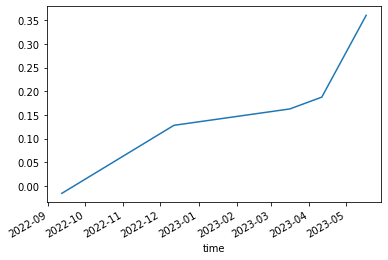

In [31]:
# Creates list with all estimated bias from scenarios (divides the sum of bias by the number of entries)
error_CAB01_df['bias'].plot()

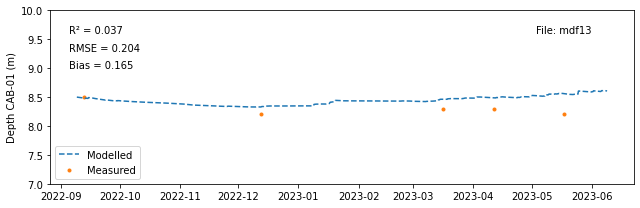

In [32]:
# Plot model x measured for depth
# Plot time series - hourly data
# ax.get_xlim()[-1]

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3], sharex = False, sharey = False)

pal = sns.color_palette("tab10", 6) # set color range

ax.plot(depth_model_CAB01.index, depth_model_CAB01['depth_CAB01_control'], linewidth='1.5', label = 'Modelled', 
        linestyle = '--', color = pal.as_hex()[0])
ax.scatter(depth_CAB01.index, depth_CAB01['depth_m'], marker = '.', label = 'Measured', color = pal.as_hex()[1])

ax.yaxis.set_label_text('Depth CAB-01 (m)', size = 10)

file = (os.path.basename(all_files[0])[5:10])
ax.text(19480, 9.6, f'File: {file}', color = 'k', fontsize = 10)

ax.text(19240, 9.6, 'R² = %0.3f' % r2_depth, color = 'k', fontsize = 10)
ax.text(19240, 9.3, 'RMSE = %0.3f' % RMSE_depth, color = 'k', fontsize = 10)
ax.text(19240, 9, 'Bias = %0.3f' % bias_depth, color = 'k', fontsize = 10)

# Add legends
ax.legend(loc = "lower left")

ax.set_ylim(7,10)

# Plot settings
# fig.text(-0.01, 0.5, 'Temperature (ºC)', va = 'center', rotation = 'vertical')
# fig.subplots_adjust(top = 0.94)

plt.tight_layout()

# Save graph
# plt.savefig('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/calibration/mdf15/WL_calibration_mdf15.jpeg', dpi=300)

plt.show();

# Modelled water temperature

CAB LOCATION

In [33]:
# Read files and add columns for each run - CAB01 LOCATION (maximum depth = 14.05 m)
for file in range(1,2,1):
    map_mdf = xr.open_dataset(all_files[file], decode_times = True)
    temporary = map_mdf['R1'].sel(M = 24, N = 37).to_dataframe()
    temporary.rename(columns = {temporary.columns[2]:('WT_CAB01_' + 
                                                      os.path.basename(all_files[file])[5:8])}, inplace = True)
    temporary.reset_index(inplace = True)
    temporary.drop('LSTSCI', axis = 1, inplace = True)
    temporary.rename(columns = {temporary.columns[1]:'layer_centre'}, inplace = True)
    temporary.set_index('time', inplace = True)
    temporary.drop(temporary.columns[[1,2]], axis = 1, inplace = True)
    temporary = temporary[temporary['WT_CAB01_' + 
                                    os.path.basename(all_files[file])[5:8]] != -999]
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time'], format = "%Y-%m-%d %H:%M:%S")
    # Join result to dataframe with control run output for comparison
    if file == 1:
        comp_wt_CAB = temporary.copy()
    else:
        comp_wt_CAB = comp_wt_CAB.merge(temporary, on = ['time', 'layer_centre'])

comp_wt_CAB.head(2)

,time,layer_centre,WT_CAB01_mdf
0,2022-09-09,0,24.320000
1,2022-09-09,1,24.690001


In [34]:
pd.options.mode.chained_assignment = None  # default='warn'

In [35]:
# Creates new column with depth
model_wt_cab = comp_wt_CAB.copy()

for timestep in range(0, len(model_wt_cab['time'].unique()), 1):
    # create copy of modelled water temperature df at the timestep analysed
    temp = model_wt_cab[model_wt_cab['time'] == model_wt_cab['time'].unique()[timestep]]

    # Gets depth at the timestep analysed
    depth_model = depth_model_CAB01.copy()
    depth_model = depth_model[depth_model.index == (model_wt_cab['time'].unique()[timestep])]

    # Creates column with depth at the timestep
    temp['max_depth'] = float(depth_model.iloc[0,1])

    # Creates column with the corresponding layer thickness 
    temp['layer_thickness'] = temp['layer_centre'].apply(layer_thickness)
    # Creates column with value of half the thickness of the layer - WT output is at the middle of a layer
    temp['middle_layer'] = (temp['layer_thickness'] / 2)

    # calculates cummulative water head relative to the bottom
    temp['cum_depth_frombottom'] = temp.loc[:, ('layer_thickness')].cumsum()

    # creates column with depth from the surface
    depths = []

    for layer in range(0, len(temp['layer_centre']), 1):
        max_depth = (float(temp.iloc[0,3]))
        half_layer_zero = float(temp.iloc[0,5])

        if layer == 0:
            # maximum depth minus half the first layer from the bottom up
            depth = (max_depth - half_layer_zero)
            depths.append(depth)
        elif layer == float(temp.iloc[-1,1]):
            # maximum depth minus cum sum from bottom up divided by two (middle of a cell)
            cum_depth_previous = float(temp.iloc[layer-1,6])
            half_current_layer = ((max_depth - cum_depth_previous) / 2)
            depth = half_current_layer
            depths.append(depth)
        else:
            depth_previous = float(temp.iloc[layer - 1,6])
            half_current_layer = ((float(temp.iloc[layer,6]) - float(temp.iloc[layer-1,6])) / 2)
            # maximum depth minus cum sum from bottom up 
            depth = (max_depth - (depth_previous + half_current_layer))
            depths.append(depth)

    temp['depth_from_surface'] = depths

    # subsets df with only relevant columns
    temp = temp[['time', 'depth_from_surface', 'WT_CAB01_mdf']]
    
    # Join result to dataframe with control run output for comparison
    if timestep == 0:
        model_wt_depths_CAB = temp.copy()
    else:
        model_wt_depths_CAB = pd.concat([model_wt_depths_CAB, temp])

model_wt_depths_CAB['depth_from_surface'] = model_wt_depths_CAB['depth_from_surface'].apply(round, args = (2,))
model_wt_depths_CAB.head(10)

,time,depth_from_surface,WT_CAB01_mdf
0,2022-09-09 00:00:00,7.58,24.320000
1,2022-09-09 00:00:00,6.19,24.690001
2,2022-09-09 00:00:00,5.26,25.070000
3,2022-09-09 00:00:00,4.34,25.440001
4,2022-09-09 00:00:00,3.42,25.309999
5,2022-09-09 00:00:00,2.49,25.420000
6,2022-09-09 00:00:00,1.57,25.530001
7,2022-09-09 00:00:00,0.64,25.629999
8,2022-09-09 00:00:00,0.09,25.740000
9,2022-09-09 06:00:00,7.57,24.345984


In [36]:
# creates new df with interpolated temperature values according to measured depths
steps = model_wt_depths_CAB.time.unique()

for step in steps:
    # Interpolate model output to match measurements
    temporary_interp = model_wt_depths_CAB.copy()
    temporary_interp.set_index('time', inplace = True)
    temporary_interp = temporary_interp.loc[step,:]
    
    # Create df with measurements depths
    measured_depths = [0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9] # list with measurement depths values
    measured_depths = pd.DataFrame(measured_depths, columns = ['depth_from_surface']) # columns names need to match the next one
    measured_depths['time'] = temporary_interp.index[0] # gets timestep
    measured_depths.set_index('time', inplace = True)

    # concatenates the two dfs and organises - sort depth column 
    temporary_interp = pd.concat([temporary_interp, measured_depths])
    temporary_interp.reset_index(inplace = True)
    temporary_interp.set_index('depth_from_surface', inplace = True)
    temporary_interp.sort_index(inplace = True)

    # Interpolates temperature values according to target measured depth
    temporary_interp['WT_CAB01_mdf'].interpolate('index', limit_area = 'inside', inplace = True)

    # Creates dfs with only measured depths
    measured_depths.reset_index(inplace = True)
    measured_depths.set_index('depth_from_surface', inplace = True)
    temporary_interp = measured_depths.merge(temporary_interp, on = ['depth_from_surface', 'time'])

    # Reorganise df 
    temporary_interp.reset_index(inplace = True)
    temporary_interp.set_index('time', inplace = True)

    if step == steps[0]:
        model_wt_interp_CAB = temporary_interp
    else: 
        model_wt_interp_CAB = pd.concat([model_wt_interp_CAB, temporary_interp])

model_wt_interp_CAB.head(2)

,depth_from_surface,WT_CAB01_mdf
time,,
2022-09-09,0.5,25.657999
2022-09-09,1.0,25.591290


BIS LOCATION

In [37]:
# Read files and add columns for each run - BIS LOCATION (maximum depth = 12.92 m)
for file in range(1,2,1):
    map_mdf = xr.open_dataset(all_files[file], decode_times = True)
    temporary = map_mdf['R1'].sel(M = 38, N = 13).to_dataframe()
    temporary.rename(columns = {temporary.columns[2]:('WT_BIS_' + 
                                                      os.path.basename(all_files[file])[5:8])}, inplace = True)
    temporary.reset_index(inplace = True)
    temporary.drop('LSTSCI', axis = 1, inplace = True)
    temporary.rename(columns = {temporary.columns[1]:'layer_centre'}, inplace = True)
    temporary.set_index('time', inplace = True)
    temporary.drop(temporary.columns[[1,2]], axis = 1, inplace = True)
    temporary = temporary[temporary['WT_BIS_' + 
                                    os.path.basename(all_files[file])[5:8]] != -999] # removes layers without output
    # layer 0 does not exist for BIS location
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time'], format = "%Y-%m-%d %H:%M:%S")
    # Join result to dataframe with control run output for comparison
    if file == 1:
        comp_wt_bis = temporary.copy()
    else:
        comp_wt_bis = comp_wt_bis.merge(temporary, on = ['time', 'layer_centre'])

comp_wt_bis.head(2)

,time,layer_centre,WT_BIS_mdf
0,2022-09-09,1,24.690001
1,2022-09-09,2,25.070000


In [38]:
# Creates new column with depth
model_wt_bis = comp_wt_bis.copy()

for timestep in range(0, len(model_wt_bis['time'].unique()), 1):
    # create copy of modelled water temperature df at the timestep analysed
    temp = model_wt_bis[model_wt_bis['time'] == model_wt_bis['time'].unique()[timestep]]

    # Gets depth at the timestep analysed
    depth_model = depth_model_BIS.copy()
    depth_model = depth_model[depth_model.index == (model_wt_bis['time'].unique()[timestep])]

    # # Creates column with depth at the timestep
    temp['max_depth'] = float(depth_model.iloc[0,1])

    # # Creates column with the corresponding layer thickness 
    temp['layer_thickness'] = temp['layer_centre'].apply(layer_thickness)
    # # Creates column with value of half the thickness of the layer - WT output is at the middle of a layer
    temp['middle_layer'] = (temp['layer_thickness'] / 2)

    # # calculates cummulative water head relative to the bottom
    temp['cum_depth_frombottom'] = temp.loc[:, ('layer_thickness')].cumsum()

    # # creates column with depth from the surface
    depths = []

    for layer in range(0, len(temp['layer_centre']), 1):
        max_depth = (float(temp.iloc[0,3]))
        temp.iloc[-1,6] = max_depth
        half_layer_bottom = float(temp.iloc[0,5])

        if layer == 0:
            # maximum depth minus half the first layer from the bottom up
            depth = (max_depth - half_layer_bottom)
            depths.append(depth)
        elif layer == float(temp.iloc[-1,1]):
            # maximum depth minus cum sum from bottom up divided by two (middle of a cell)
            cum_depth_previous = float(temp.iloc[layer-1,6])
            half_current_layer = ((max_depth - cum_depth_previous) / 2)
            depth = half_current_layer
            depths.append(depth)
        else:
            depth_previous = float(temp.iloc[layer - 1,6])
            half_current_layer = ((float(temp.iloc[layer,6]) - float(temp.iloc[layer-1,6])) / 2)
            # maximum depth minus cum sum from bottom up 
            depth = (max_depth - (depth_previous + half_current_layer))
            depths.append(depth)

    temp['depth_from_surface'] = depths

    # subsets df with only relevant columns
    temp = temp[['time', 'depth_from_surface', 'WT_BIS_mdf']]
    
    # Join result to dataframe with control run output for comparison
    if timestep == 0:
        model_wt_depths_BIS = temp.copy()
    else:
        model_wt_depths_BIS = pd.concat([model_wt_depths_BIS, temp])

model_wt_depths_BIS['depth_from_surface'] = model_wt_depths_BIS['depth_from_surface'].apply(round, args = (2,))
model_wt_depths_BIS.head(3)

,time,depth_from_surface,WT_BIS_mdf
0,2022-09-09,6.19,24.690001
1,2022-09-09,5.26,25.070000
2,2022-09-09,4.34,25.440001


In [39]:
# creates new df with interpolated temperature values according to measured depths
steps = model_wt_depths_BIS.time.unique()

for step in steps:
    # Interpolate model output to match measurements
    temporary_interp = model_wt_depths_BIS.copy()
    temporary_interp.set_index('time', inplace = True)
    temporary_interp = temporary_interp.loc[step,:]
    
    # Create df with measurements depths
    measured_depths = [0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9] # list with measurement depths values
    measured_depths = pd.DataFrame(measured_depths, columns = ['depth_from_surface']) # columns names need to match the next one
    measured_depths['time'] = temporary_interp.index[0] # gets timestep
    measured_depths.set_index('time', inplace = True)

    # concatenates the two dfs and organises - sort depth column 
    temporary_interp = pd.concat([temporary_interp, measured_depths])
    temporary_interp.reset_index(inplace = True)
    temporary_interp.set_index('depth_from_surface', inplace = True)
    temporary_interp.sort_index(inplace = True)

    # Interpolates temperature values according to target measured depth
    temporary_interp['WT_BIS_mdf'].interpolate('index', limit_area = 'inside', inplace = True)

    # Creates dfs with only measured depths
    measured_depths.reset_index(inplace = True)
    measured_depths.set_index('depth_from_surface', inplace = True)
    temporary_interp = measured_depths.merge(temporary_interp, on = ['depth_from_surface', 'time'])

    # Reorganise df 
    temporary_interp.reset_index(inplace = True)
    temporary_interp.set_index('time', inplace = True)

    if step == steps[0]:
        model_wt_interp_BIS = temporary_interp
    else: 
        model_wt_interp_BIS = pd.concat([model_wt_interp_BIS, temporary_interp])

model_wt_interp_BIS.head(3)

,depth_from_surface,WT_BIS_mdf
time,,
2022-09-09,0.5,25.657999
2022-09-09,1.0,25.591290
2022-09-09,2.0,25.478588


# Quantitative comparison

CAB LOCATION

In [40]:
# Make a df similar to the measurements for the modelled
for step in range(0, len(model_wt_interp_CAB['depth_from_surface'].unique()), 1):
    temp = model_wt_interp_CAB[(model_wt_interp_CAB['depth_from_surface'] == 
                                model_wt_interp_CAB['depth_from_surface'].unique()[step])]
    temp.rename(columns = {temp.columns[1]:('WT_CAB_' + 
                                            str(temp.iloc[0,0]) + 
                                            'm_model')}, inplace = True)
    temp.drop('depth_from_surface', axis = 1, inplace = True)
    if step == 0:
        WT_CAB_model_format = temp
    else:
        WT_CAB_model_format = WT_CAB_model_format.join(temp, how = 'outer')

WT_CAB_model_format.head(3)

,WT_CAB_0.5m_model,WT_CAB_1.0m_model,WT_CAB_2.0m_model,WT_CAB_3.0m_model,WT_CAB_4.0m_model,WT_CAB_5.0m_model,WT_CAB_6.0m_model,WT_CAB_7.0m_model,WT_CAB_8.0m_model,WT_CAB_9.0m_model
time,,,,,,,,,,
2022-09-09 00:00:00,25.657999,25.591290,25.478588,25.359676,25.391956,25.174564,24.767635,24.474388,NaN,NaN
2022-09-09 06:00:00,25.173302,25.185385,25.196529,25.203331,25.207712,25.209913,24.799526,24.489754,NaN,NaN
2022-09-09 12:00:00,25.131195,25.147499,25.163074,25.171869,25.176294,25.145920,24.768852,24.550335,NaN,NaN


In [41]:
### DF for calculating bias (model WT - measured WT) - CAB LOCATION

## Measured data - stored in a Dictionary
# Create dataframe with all measurements with matching index and all depths
depths_CAB = ['WT_CAB_0.5m_field', 'WT_CAB_1m_field', 'WT_CAB_2m_field', 'WT_CAB_3m_field',
              'WT_CAB_4m_field', 'WT_CAB_5m_field', 'WT_CAB_6m_field', 'WT_CAB_7m_field', 
              'WT_CAB_8m_field', 'WT_CAB_9m_field']

for step in range(0, len(List), 1):
    temp = Dictionary[List[step]].copy()
    temp.reset_index(inplace = True)
    temp.rename(columns = {temp.columns[0]:'time', 
                           temp.columns[1]:depths_CAB[step]}, inplace = True)
    temp['time'] = pd.to_datetime(temp['time'], format = "%Y-%m-%d %H:%M:%S")
    temp.set_index('time', inplace = True)
    # create joined df
    if step == 0:
        WT_CAB_measured_full = temp
    else:
        WT_CAB_measured_full = WT_CAB_measured_full.merge(temp, on = ['time'])

# WT_measured_full.drop(WT_measured_full.columns[0], axis = 1, inplace = True) # excludes 0.5m measurements from df
WT_CAB_measured_full.head(2)

,WT_CAB_0.5m_field,WT_CAB_1m_field,WT_CAB_2m_field,WT_CAB_3m_field,WT_CAB_4m_field,WT_CAB_5m_field,WT_CAB_6m_field,WT_CAB_7m_field,WT_CAB_8m_field,WT_CAB_9m_field
time,,,,,,,,,,
2022-09-09 00:00:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,NaN,24.32
2022-09-09 00:10:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,NaN,24.36


In [42]:
## Now join full datasets to be able to calculate quantitative error
WT_CAB_model_comp = WT_CAB_model_format.copy()
WT_CAB_measure_comp = WT_CAB_measured_full.copy()

# Merge dfs wit
WT_CAB_quant_compare = WT_CAB_measure_comp.merge(WT_CAB_model_comp, on = ['time'])

WT_CAB_quant_compare.head(2)

,WT_CAB_0.5m_field,WT_CAB_1m_field,WT_CAB_2m_field,WT_CAB_3m_field,WT_CAB_4m_field,WT_CAB_5m_field,WT_CAB_6m_field,WT_CAB_7m_field,WT_CAB_8m_field,WT_CAB_9m_field,WT_CAB_0.5m_model,WT_CAB_1.0m_model,WT_CAB_2.0m_model,WT_CAB_3.0m_model,WT_CAB_4.0m_model,WT_CAB_5.0m_model,WT_CAB_6.0m_model,WT_CAB_7.0m_model,WT_CAB_8.0m_model,WT_CAB_9.0m_model
time,,,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,25.74,NaN,NaN,NaN,25.31,25.44,NaN,NaN,NaN,24.32,25.657999,25.591290,25.478588,25.359676,25.391956,25.174564,24.767635,24.474388,NaN,NaN
2022-09-09 06:00:00,25.39,NaN,NaN,NaN,25.27,25.39,NaN,NaN,NaN,24.28,25.173302,25.185385,25.196529,25.203331,25.207712,25.209913,24.799526,24.489754,NaN,NaN


In [43]:
# Calculate bias column
for depth in range(0, len(WT_CAB_measure_comp.columns), 1):
    WT_CAB_quant_compare[('bias_' + 
                          WT_CAB_quant_compare.columns[depth][7:9])] = (WT_CAB_quant_compare[WT_CAB_model_comp.columns[depth]] -
                                                                        WT_CAB_quant_compare[WT_CAB_measure_comp.columns[depth]])
bias_WT_CAB_df = WT_CAB_quant_compare[WT_CAB_quant_compare.columns[20:]]
bias_WT_CAB_df.head(2)

,bias_0.,bias_1m,bias_2m,bias_3m,bias_4m,bias_5m,bias_6m,bias_7m,bias_8m,bias_9m
time,,,,,,,,,,
2022-09-09 00:00:00,-0.082001,NaN,NaN,NaN,0.081956,-0.265436,NaN,NaN,NaN,NaN
2022-09-09 06:00:00,-0.216698,NaN,NaN,NaN,-0.062288,-0.180087,NaN,NaN,NaN,NaN


BIS LOCATION

In [44]:
# Make a df similar to the measurements for the modelled
for step in range(0, len(model_wt_interp_BIS['depth_from_surface'].unique()), 1):
    temp = model_wt_interp_BIS[(model_wt_interp_BIS['depth_from_surface'] == 
                                model_wt_interp_BIS['depth_from_surface'].unique()[step])]
    temp.rename(columns = {temp.columns[1]:('WT_CAB_' + 
                                            str(temp.iloc[0,0]) + 
                                            'm_model')}, inplace = True)
    temp.drop('depth_from_surface', axis = 1, inplace = True)
    if step == 0:
        WT_BIS_model_format = temp
    else:
        WT_BIS_model_format = WT_BIS_model_format.join(temp, how = 'outer')

WT_BIS_model_format.head(3)

,WT_CAB_0.5m_model,WT_CAB_1.0m_model,WT_CAB_2.0m_model,WT_CAB_3.0m_model,WT_CAB_4.0m_model,WT_CAB_5.0m_model,WT_CAB_6.0m_model,WT_CAB_7.0m_model,WT_CAB_8.0m_model,WT_CAB_9.0m_model
time,,,,,,,,,,
2022-09-09 00:00:00,25.657999,25.591290,25.478588,25.359676,25.391956,25.174564,24.767635,NaN,NaN,NaN
2022-09-09 06:00:00,25.171501,25.184259,25.195799,25.202816,25.207384,25.209904,24.799866,NaN,NaN,NaN
2022-09-09 12:00:00,25.126167,25.144054,25.161255,25.171021,25.176064,25.167618,24.815222,NaN,NaN,NaN


In [45]:
### DF for calculating bias (model WT - measured WT) - BIS location

## Measured data - stored in a Dictionary_BIS
# Create dataframe with all measurements with matching index and all depths
depths_BIS = ['WT_BIS_0.5m_field', 'WT_BIS_1m_field', 'WT_BIS_2m_field', 'WT_BIS_3m_field',
              'WT_BIS_4m_field', 'WT_BIS_5m_field', 'WT_BIS_6m_field', 'WT_BIS_7m_field', 
              'WT_BIS_8m_field', 'WT_BIS_9m_field']
List = all_data_T_BIS.columns[1:].sort_values()

for step in range(0, len(List), 1):
    temp = Dictionary_BIS[List[step]].copy()
    temp = temp.loc['2022-09-09 00:00:00':]
    temp.reset_index(inplace = True)
    temp.rename(columns = {temp.columns[0]:'time', 
                           temp.columns[1]:depths_BIS[step]}, inplace = True)
    temp['time'] = pd.to_datetime(temp['time'], format = "%Y-%m-%d %H:%M:%S")
    temp.set_index('time', inplace = True)
    # create joined df
    if step == 0:
        WT_BIS_measured_full = temp
    else:
        WT_BIS_measured_full = WT_BIS_measured_full.merge(temp, on = ['time'], how = 'inner')

# WT_measured_full.drop(WT_measured_full.columns[0], axis = 1, inplace = True) # excludes 0.5m measurements from df
WT_BIS_measured_full.head(2)

,WT_BIS_0.5m_field,WT_BIS_1m_field,WT_BIS_2m_field,WT_BIS_3m_field,WT_BIS_4m_field,WT_BIS_5m_field,WT_BIS_6m_field,WT_BIS_7m_field,WT_BIS_8m_field,WT_BIS_9m_field
time,,,,,,,,,,
2022-09-27 00:00:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-27 00:10:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
## Now join full datasets to be able to calculate quantitative error
WT_BIS_model_comp = WT_BIS_model_format.copy()
WT_BIS_measure_comp = WT_BIS_measured_full.copy()

# Merge dfs wit
WT_BIS_quant_compare = WT_BIS_measure_comp.merge(WT_BIS_model_comp, on = ['time'])

WT_BIS_quant_compare.head(2)

,WT_BIS_0.5m_field,WT_BIS_1m_field,WT_BIS_2m_field,WT_BIS_3m_field,WT_BIS_4m_field,WT_BIS_5m_field,WT_BIS_6m_field,WT_BIS_7m_field,WT_BIS_8m_field,WT_BIS_9m_field,WT_CAB_0.5m_model,WT_CAB_1.0m_model,WT_CAB_2.0m_model,WT_CAB_3.0m_model,WT_CAB_4.0m_model,WT_CAB_5.0m_model,WT_CAB_6.0m_model,WT_CAB_7.0m_model,WT_CAB_8.0m_model,WT_CAB_9.0m_model
time,,,,,,,,,,,,,,,,,,,,
2022-09-27 00:00:00,22.238,22.238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.500687,21.517576,21.533627,21.543222,21.550091,21.555401,21.559780,NaN,NaN,NaN
2022-09-27 06:00:00,21.855,21.855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.261572,21.275839,21.290333,21.299435,21.306053,21.311203,21.315428,NaN,NaN,NaN


In [47]:
# Calculate bias column
for depth in range(0, len(WT_BIS_measure_comp.columns), 1):
    WT_BIS_quant_compare[('bias_' + 
                          WT_BIS_quant_compare.columns[depth][7:9])] = (WT_BIS_quant_compare[WT_BIS_model_comp.columns[depth]] -
                                                                        WT_BIS_quant_compare[WT_BIS_measure_comp.columns[depth]])
bias_WT_BIS_df = WT_BIS_quant_compare[WT_BIS_quant_compare.columns[20:]]
bias_WT_BIS_df.tail(2)

,bias_0.,bias_1m,bias_2m,bias_3m,bias_4m,bias_5m,bias_6m,bias_7m,bias_8m,bias_9m
time,,,,,,,,,,
2023-06-08 12:00:00,1.229434,1.614359,1.480281,-0.071936,-2.576565,-3.817355,-1.671617,NaN,NaN,NaN
2023-06-08 18:00:00,2.005984,2.135896,1.853584,0.178652,-2.349572,-4.164049,-1.710301,NaN,NaN,NaN


# Metrics - WT

CAB location

In [48]:
# Subset columns for comparison - matching depths for WT (basically exclude bias)
WT_CAB_formetrics = WT_CAB_quant_compare[['WT_CAB_0.5m_field', 'WT_CAB_1m_field', 'WT_CAB_2m_field',
                                          'WT_CAB_3m_field', 'WT_CAB_4m_field', 'WT_CAB_5m_field',
                                          'WT_CAB_6m_field', 'WT_CAB_7m_field', 'WT_CAB_8m_field',
                                          'WT_CAB_9m_field', 'WT_CAB_0.5m_model', 'WT_CAB_1.0m_model',
                                          'WT_CAB_2.0m_model', 'WT_CAB_3.0m_model', 'WT_CAB_4.0m_model',
                                          'WT_CAB_5.0m_model', 'WT_CAB_6.0m_model', 'WT_CAB_7.0m_model',
                                          'WT_CAB_8.0m_model', 'WT_CAB_9.0m_model']]

WT_CAB_formetrics.columns

Index(['WT_CAB_0.5m_field', 'WT_CAB_1m_field', 'WT_CAB_2m_field',
       'WT_CAB_3m_field', 'WT_CAB_4m_field', 'WT_CAB_5m_field',
       'WT_CAB_6m_field', 'WT_CAB_7m_field', 'WT_CAB_8m_field',
       'WT_CAB_9m_field', 'WT_CAB_0.5m_model', 'WT_CAB_1.0m_model',
       'WT_CAB_2.0m_model', 'WT_CAB_3.0m_model', 'WT_CAB_4.0m_model',
       'WT_CAB_5.0m_model', 'WT_CAB_6.0m_model', 'WT_CAB_7.0m_model',
       'WT_CAB_8.0m_model', 'WT_CAB_9.0m_model'],
      dtype='object')

In [49]:
# Creates complete dataset of measurements + gaps for each depth - one dataframe per depth
List_depth_field_CAB = WT_CAB_formetrics.columns[0:10]
List_depth_model_CAB = WT_CAB_formetrics.columns[10:]
r2_list = []
RMSE_list = []
Dictionary_WT_CAB = {}

for i in range(0, len(List_depth_field_CAB), 1):
    name = str(List_depth_field_CAB[i][0:-6])
    Dictionary_WT_CAB[name] = pd.DataFrame()
    Dictionary_WT_CAB[name] = WT_CAB_formetrics[[List_depth_field_CAB[i], List_depth_model_CAB[i]]]
#     Dictionary_WT_CAB[name] = Dictionary_WT_CAB[name].dropna()

Dictionary_WT_CAB

{'WT_CAB_0.5m':                      WT_CAB_0.5m_field  WT_CAB_0.5m_model
 time                                                     
 2022-09-09 00:00:00             25.740          25.657999
 2022-09-09 06:00:00             25.390          25.173302
 2022-09-09 12:00:00             25.480          25.131195
 2022-09-09 18:00:00             25.390          25.095510
 2022-09-10 00:00:00             25.090          24.815680
 ...                                ...                ...
 2023-06-07 18:00:00             23.484          25.454313
 2023-06-08 00:00:00             22.908          24.786869
 2023-06-08 06:00:00             22.717          24.297956
 2023-06-08 12:00:00             23.773          25.037979
 2023-06-08 18:00:00             23.100          25.120646
 
 [1119 rows x 2 columns],
 'WT_CAB_1m':                      WT_CAB_1m_field  WT_CAB_1.0m_model
 time                                                   
 2022-09-09 00:00:00              NaN          25.591290
 2022-

In [50]:
# Calculates metrics for each depth
dict_names = ['WT_CAB_0.5m','WT_CAB_1m', 'WT_CAB_2m', 'WT_CAB_3m', 'WT_CAB_4m', 'WT_CAB_5m', 
              'WT_CAB_6m', 'WT_CAB_7m', 'WT_CAB_8m', 'WT_CAB_9m']
r2_list = []
RMSE_list = []
bias_list = []

for depth in range(0, len(Dictionary_WT_CAB), 1):
    temp = Dictionary_WT_CAB[dict_names[depth]].dropna()
    n = len(temp)
    try:
        r2 = ((np.corrcoef(temp[temp.columns[0]], temp[temp.columns[1]])[0,1]) ** 2)
        temp['sq_error'] = ((temp[temp.columns[0]] - temp[temp.columns[1]]) ** 2)
        RMSE = (((1/n) * (temp['sq_error'].sum()) ) ** 0.5)
        bias = (((temp[temp.columns[1]] - temp[temp.columns[0]]).sum()) / n)
    except:
        r2 = np.nan
        RMSE = np.nan
        bias = np.nan
    # Join results into lists
    r2_list.append(r2)
    RMSE_list.append(RMSE)
    bias_list.append(bias)

print('r²:', r2_list)
print('')
print('RMSE:', RMSE_list)
print('')
print('Bias:', bias_list)

r²: [0.9857731368191932, 0.986661903119883, 0.9873290600981623, 0.9862559739647152, 0.9826225888312531, 0.9807007306787188, 0.9782363233308093, 0.9804135414752909, nan, nan]

RMSE: [1.2930729709307078, 1.2500926363461975, 1.17330027865301, 1.2116655000573286, 1.2794769287623466, 1.3634014124569571, 1.3771971685555484, 1.2309474338097426, nan, nan]

Bias: [-0.7143142895980109, -0.6069641367244261, -0.5262350118904298, -0.7447135330366051, -0.862993728121803, -0.9766117168735322, -0.9826376856578144, -0.7833521913685085, nan, nan]


C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: inval

In [51]:
# Creates dfs with error according to depth
WT_CAB_metrics = pd.DataFrame()
WT_CAB_metrics['depths'] = dict_names
WT_CAB_metrics['r2_CAB_location'] = r2_list
WT_CAB_metrics['RMSE_CAB_location'] = RMSE_list
WT_CAB_metrics['Bias_CAB_location'] = bias_list

WT_CAB_metrics.head(2)

,depths,r2_CAB_location,RMSE_CAB_location,Bias_CAB_location
0,WT_CAB_0.5m,0.985773,1.293073,-0.714314
1,WT_CAB_1m,0.986662,1.250093,-0.606964


In [48]:
WT_CAB_metrics.to_csv('WT_CAB_metrics_mdf15.csv')

BIS location

In [52]:
# Subset columns for comparison - matching depths for WT (basically exclude bias and 8.6m from model)
WT_BIS_formetrics = WT_BIS_quant_compare[['WT_BIS_0.5m_field', 'WT_BIS_1m_field', 'WT_BIS_2m_field',
                                          'WT_BIS_3m_field', 'WT_BIS_4m_field', 'WT_BIS_5m_field',
                                          'WT_BIS_6m_field', 'WT_BIS_7m_field', 'WT_BIS_8m_field',
                                          'WT_BIS_9m_field', 'WT_CAB_0.5m_model', 'WT_CAB_1.0m_model',
                                          'WT_CAB_2.0m_model', 'WT_CAB_3.0m_model', 'WT_CAB_4.0m_model',
                                          'WT_CAB_5.0m_model', 'WT_CAB_6.0m_model', 'WT_CAB_7.0m_model',
                                          'WT_CAB_8.0m_model', 'WT_CAB_9.0m_model']]
WT_BIS_formetrics.columns

Index(['WT_BIS_0.5m_field', 'WT_BIS_1m_field', 'WT_BIS_2m_field',
       'WT_BIS_3m_field', 'WT_BIS_4m_field', 'WT_BIS_5m_field',
       'WT_BIS_6m_field', 'WT_BIS_7m_field', 'WT_BIS_8m_field',
       'WT_BIS_9m_field', 'WT_CAB_0.5m_model', 'WT_CAB_1.0m_model',
       'WT_CAB_2.0m_model', 'WT_CAB_3.0m_model', 'WT_CAB_4.0m_model',
       'WT_CAB_5.0m_model', 'WT_CAB_6.0m_model', 'WT_CAB_7.0m_model',
       'WT_CAB_8.0m_model', 'WT_CAB_9.0m_model'],
      dtype='object')

In [53]:
# Creates complete dataset of measurements + gaps for each depth - one dataframe per depth
List_depth_field_BIS = WT_BIS_formetrics.columns[0:10]
List_depth_model_BIS = WT_BIS_formetrics.columns[10:]
Dictionary_WT_BIS = {}

for i in range(0, len(List_depth_field_BIS), 1):
    name = str(List_depth_field_BIS[i][0:-6])
    Dictionary_WT_BIS[name] = pd.DataFrame()
    Dictionary_WT_BIS[name] = WT_BIS_formetrics[[List_depth_field_BIS[i], List_depth_model_BIS[i]]]
#     Dictionary_WT_BIS[name] = Dictionary_WT_BIS[name].dropna()

Dictionary_WT_BIS

{'WT_BIS_0.5m':                      WT_BIS_0.5m_field  WT_CAB_0.5m_model
 time                                                     
 2022-09-27 00:00:00             22.238          21.500687
 2022-09-27 06:00:00             21.855          21.261572
 2022-09-27 12:00:00             21.855          21.177599
 2022-09-27 18:00:00             22.333          21.112495
 2022-09-28 00:00:00             21.855          20.910051
 ...                                ...                ...
 2023-06-07 18:00:00             23.484          25.442795
 2023-06-08 00:00:00             22.908          24.782867
 2023-06-08 06:00:00             22.717          24.284891
 2023-06-08 12:00:00             23.773          25.002434
 2023-06-08 18:00:00             23.100          25.105984
 
 [1047 rows x 2 columns],
 'WT_BIS_1m':                      WT_BIS_1m_field  WT_CAB_1.0m_model
 time                                                   
 2022-09-27 00:00:00           22.238          21.517576
 2022-

In [54]:
# Calculates metrics for each depth
dict_names_BIS = ['WT_BIS_0.5m','WT_BIS_1m', 'WT_BIS_2m', 'WT_BIS_3m', 'WT_BIS_4m', 'WT_BIS_5m', 
                  'WT_BIS_6m', 'WT_BIS_7m', 'WT_BIS_8m', 'WT_BIS_9m']
r2_list_BIS = []
RMSE_list_BIS = []
bias_list_BIS = []

for depth in range(0, len(Dictionary_WT_BIS), 1):
    temp = Dictionary_WT_BIS[dict_names_BIS[depth]].dropna()
    n = len(temp)
    try:
        r2 = ((np.corrcoef(temp[temp.columns[0]], temp[temp.columns[1]])[0,1]) ** 2)
        temp['sq_error'] = ((temp[temp.columns[0]] - temp[temp.columns[1]]) ** 2)
        RMSE = (((1/n) * (temp['sq_error'].sum()) ) ** 0.5)
        bias = (((temp[temp.columns[1]] - temp[temp.columns[0]]).sum()) / n)
    except:
        r2 = np.nan
        RMSE = np.nan
        bias = np.nan
    # Join results into lists
    r2_list_BIS.append(r2)
    RMSE_list_BIS.append(RMSE)
    bias_list_BIS.append(bias)

print('r²:', r2_list_BIS)
print('')
print('RMSE:', RMSE_list_BIS)
print('')
print('Bias:', bias_list_BIS)

r²: [0.9852962258203111, 0.9860061378502436, 0.9871807645558346, 0.9857941531788132, 0.9809853571506995, 0.9791213684763336, 0.9782443985439255, nan, nan, nan]

RMSE: [1.3014919178084006, 1.2467491699278013, 1.1736490164092819, 1.2172316753591734, 1.294993240843299, 1.3760234851150652, 1.3769543139180715, nan, nan, nan]

Bias: [-0.7274027388262089, -0.611414242543145, -0.5290607403667652, -0.7496785386716686, -0.8773485627584411, -0.9885849087977754, -0.9818790135517212, nan, nan, nan]


C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: inval

In [55]:
# Creates dfs with error according to depth
WT_BIS_metrics = pd.DataFrame()
WT_BIS_metrics['depths'] = dict_names_BIS
WT_BIS_metrics['r2_BIS_location'] = r2_list_BIS
WT_BIS_metrics['RMSE_BIS_location'] = RMSE_list_BIS
WT_BIS_metrics['Bias_BIS_location'] = bias_list_BIS

WT_BIS_metrics.head(2)

,depths,r2_BIS_location,RMSE_BIS_location,Bias_BIS_location
0,WT_BIS_0.5m,0.985296,1.301492,-0.727403
1,WT_BIS_1m,0.986006,1.246749,-0.611414


In [53]:
WT_BIS_metrics.to_csv('WT_BIS_metrics_mdf15.csv')

Organise data for bias boxplot with CAB and BIS locations

In [56]:
# Melt data for boxplot
data_CAB = pd.melt(bias_WT_CAB_df[[bias_WT_CAB_df.columns[0], bias_WT_CAB_df.columns[1], bias_WT_CAB_df.columns[2],
                                   bias_WT_CAB_df.columns[3], bias_WT_CAB_df.columns[4], bias_WT_CAB_df.columns[5],
                                   bias_WT_CAB_df.columns[6], bias_WT_CAB_df.columns[7], bias_WT_CAB_df.columns[8],
                                   bias_WT_CAB_df.columns[9]]])

data_BIS = pd.melt(bias_WT_BIS_df[[bias_WT_BIS_df.columns[0], bias_WT_BIS_df.columns[1], bias_WT_BIS_df.columns[2],
                                   bias_WT_BIS_df.columns[3], bias_WT_BIS_df.columns[4], bias_WT_BIS_df.columns[5],
                                   bias_WT_BIS_df.columns[6], bias_WT_BIS_df.columns[7], bias_WT_BIS_df.columns[8],
                                   bias_WT_BIS_df.columns[9]]])

In [59]:
bias_WT_CAB_df.head()

,bias_0.,bias_1m,bias_2m,bias_3m,bias_4m,bias_5m,bias_6m,bias_7m,bias_8m,bias_9m
time,,,,,,,,,,
2022-09-09 00:00:00,-0.082001,NaN,NaN,NaN,0.081956,-0.265436,NaN,NaN,NaN,NaN
2022-09-09 06:00:00,-0.216698,NaN,NaN,NaN,-0.062288,-0.180087,NaN,NaN,NaN,NaN
2022-09-09 12:00:00,-0.348805,NaN,NaN,NaN,-0.003706,-0.204080,NaN,NaN,NaN,NaN
2022-09-09 18:00:00,-0.294490,NaN,NaN,NaN,-0.002137,-0.171296,NaN,NaN,NaN,NaN
2022-09-10 00:00:00,-0.274320,NaN,NaN,NaN,-0.119666,-0.235918,NaN,NaN,NaN,NaN


In [57]:
bias_boxplot_df = bias_WT_CAB_df.copy()

# Creates columns with month
bias_boxplot_df['month'] = bias_boxplot_df.index.month
bias_boxplot_df['month_str'] = bias_boxplot_df['month'].apply(lambda x: calendar.month_abbr[x])

bias_boxplot_df

,bias_0.,bias_1m,bias_2m,bias_3m,bias_4m,bias_5m,bias_6m,bias_7m,bias_8m,bias_9m,month,month_str
time,,,,,,,,,,,,
2022-09-09 00:00:00,-0.082001,NaN,NaN,NaN,0.081956,-0.265436,NaN,NaN,NaN,NaN,9,Sep
2022-09-09 06:00:00,-0.216698,NaN,NaN,NaN,-0.062288,-0.180087,NaN,NaN,NaN,NaN,9,Sep
2022-09-09 12:00:00,-0.348805,NaN,NaN,NaN,-0.003706,-0.204080,NaN,NaN,NaN,NaN,9,Sep
2022-09-09 18:00:00,-0.294490,NaN,NaN,NaN,-0.002137,-0.171296,NaN,NaN,NaN,NaN,9,Sep
2022-09-10 00:00:00,-0.274320,NaN,NaN,NaN,-0.119666,-0.235918,NaN,NaN,NaN,NaN,9,Sep
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-07 18:00:00,1.970313,2.081854,1.775625,-0.257506,-2.857249,-1.810230,-1.549109,-1.128932,NaN,NaN,6,Jun
2023-06-08 00:00:00,1.878869,1.894586,1.868225,0.214860,-2.437608,-1.501546,-1.530631,-1.113995,NaN,NaN,6,Jun
2023-06-08 06:00:00,1.580956,1.689356,1.794834,0.459666,-2.194957,-1.560548,-1.509638,-1.194461,NaN,NaN,6,Jun


In [58]:
# Creates a single df to plot boxplot with CAB and BIS locations into one plot
bias_boxplot_df = bias_WT_CAB_df.copy()

bias_boxplot_df['month'] = bias_boxplot_df.index.month
bias_boxplot_df['month_str'] = bias_boxplot_df['month'].apply(lambda x: calendar.month_abbr[x])

bias_boxplot_df.reset_index(drop = True, inplace = True)
bias_boxplot_df['loc'] = 'CAB'

temp = bias_WT_BIS_df.copy()
temp['month'] = temp.index.month
temp['month_str'] = temp['month'].apply(lambda x: calendar.month_abbr[x])
temp.reset_index(drop = True, inplace = True)
temp['loc'] = 'BIS'

bias_boxplot_df = pd.concat([bias_boxplot_df, temp])
bias_boxplot_df.head(2)

,bias_0.,bias_1m,bias_2m,bias_3m,bias_4m,bias_5m,bias_6m,bias_7m,bias_8m,bias_9m,month,month_str,loc
0,-0.082001,NaN,NaN,NaN,0.081956,-0.265436,NaN,NaN,NaN,NaN,9,Sep,CAB
1,-0.216698,NaN,NaN,NaN,-0.062288,-0.180087,NaN,NaN,NaN,NaN,9,Sep,CAB


In [59]:
# Adjusts format to one dataframe

for depth in range(0, len(bias_boxplot_df.columns)-3,1):
    temp = pd.DataFrame(bias_boxplot_df[bias_boxplot_df.columns[[depth,-2,-1]]])
    temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
    temp['depth'] = (str(depth) + 'm')
    if depth == 0:
        joined_df_boxplot = temp
    else:
        joined_df_boxplot = pd.concat([joined_df_boxplot, temp])

joined_df_boxplot.head(3)

,bias,month_str,loc,depth
0,-0.082001,Sep,CAB,0m
1,-0.216698,Sep,CAB,0m
2,-0.348805,Sep,CAB,0m


# Water temperature - plots of errors

In [60]:
# Creates list with legend for figure

legends = []

for depth in range(0,len(bias_WT_CAB_df.columns),1):
    if depth == 0:
        legend = '0.5m'
        legends.append(legend)
    else:
        legend = bias_WT_CAB_df.columns[depth][5:8]
        legends.append(legend)

legends

['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m', '8m', '9m']

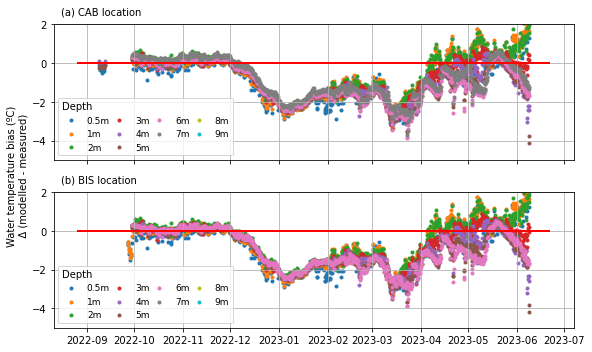

In [61]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [8,5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)

for depth in range(0, len(bias_WT_CAB_df.columns), 1):
    ax[0].scatter(bias_WT_CAB_df.index, bias_WT_CAB_df[bias_WT_CAB_df.columns[depth]],
                  marker = '.', color = pal.as_hex()[depth], zorder = 1,
                  label = legends[depth])
    ax[0].hlines(y = 0, xmin = 19230, xmax = 19530, color = 'r')
    ax[0].grid(True, zorder = -1)

for depth in range(0, len(bias_WT_BIS_df.columns), 1):
    ax[1].scatter(bias_WT_BIS_df.index, bias_WT_BIS_df[bias_WT_BIS_df.columns[depth]],
                  marker = '.', color = pal.as_hex()[depth], zorder = 1,
                  label = legends[depth])
    ax[1].hlines(y = 0, xmin = 19230, xmax = 19530, color = 'r')
    ax[1].grid(True, zorder = -1)

ax[0].legend(title = "Depth", loc="lower left", ncol = 4, fontsize = 9, 
               frameon = True, columnspacing = 0.01)._legend_box.align = "left"
ax[1].legend(title = "Depth", loc="lower left", ncol = 4, fontsize = 9, 
               frameon = True, columnspacing = 0.01)._legend_box.align = "left"

ax[0].text(19220, 2.5, '(a) CAB location', color = 'k', fontsize = 10)
ax[1].text(19220, 2.5, '(b) BIS location', color = 'k', fontsize = 10)

ax[1].set_ylim(-5,2)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Water temperature bias (ºC)\n   Δ (modelled - measured)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('bias_WT_mdf15.jpeg', dpi=600, bbox_inches='tight')

plt.show();

In [63]:
depths

['0m', '1m', '2m', '3m', '4m', '5m', '6m', '7m', '8m', '9m']

In [65]:
joined_df_boxplot['depth'].unique().tolist()[0:-2]

['0m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']

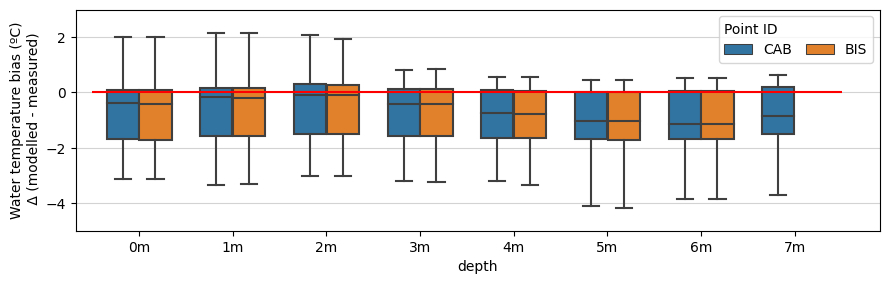

In [72]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3])

pal = sns.color_palette("tab10",5)
depths = joined_df_boxplot['depth'].unique().tolist()[0:-2]

sns.boxplot(x = "depth", y = "bias", 
            data = joined_df_boxplot.loc[joined_df_boxplot['depth'].isin(depths)],
            width = 0.7, boxprops = {'zorder': 1}, 
            palette = pal[0:2], ax = ax, hue = 'loc')

ax.set_xticks([0,1,2,3,4,5,6,7], depths,
              fontsize = 10)

ax.set_ylim(-5,3)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
       
ax.yaxis.set_label_text(u'Water temperature bias (ºC)\n Δ (modelled - measured)', fontsize = 10)

ax.legend(title = "Point ID", loc="upper right", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"

ax.hlines(y = 0, xmin = -0.5, xmax = 7.5, color = 'r')
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('bias_boxplots_CAB_BIS_mdf13.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

In [66]:
joined_df_boxplot.head(2)

,bias,month_str,loc,depth
0,-0.082001,Sep,CAB,0m
1,-0.216698,Sep,CAB,0m


In [67]:
joined_df_boxplot.month_str.unique()

array(['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May',
       'Jun'], dtype=object)

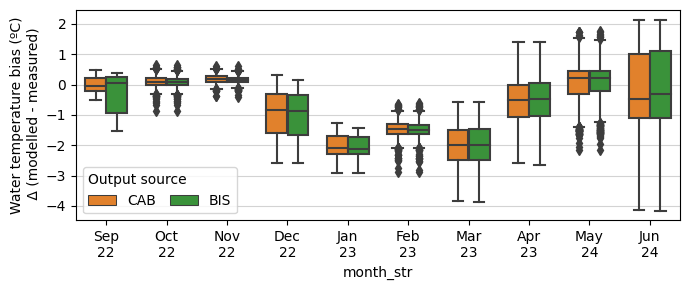

In [74]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [7,3], sharey = True)

pal = sns.color_palette("tab10",5)

# CAB location
sns.boxplot(x = "month_str", y = "bias", data = joined_df_boxplot,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax, hue = 'loc')

ax.set_xticks([0,1,2,3,4,5,6,7,8,9],
              ['Sep\n22','Oct\n22', 'Nov\n22', 'Dec\n22','Jan\n23', 'Feb\n23', 'Mar\n23','Apr\n23', 'May\n24', 'Jun\n24'],
              fontsize = 10)

# ax.set_ylim(-2,19)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Water temperature bias (ºC)\n Δ (modelled - measured)', fontsize = 10)

ax.legend(title = "Output source", loc="lower left", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

# ax.text(-0.3, 20, '(a) CAB location', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('Bias_monthly_boxplots_CAB_BIS_mdf13.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

Scatter plot per depth - model x measured

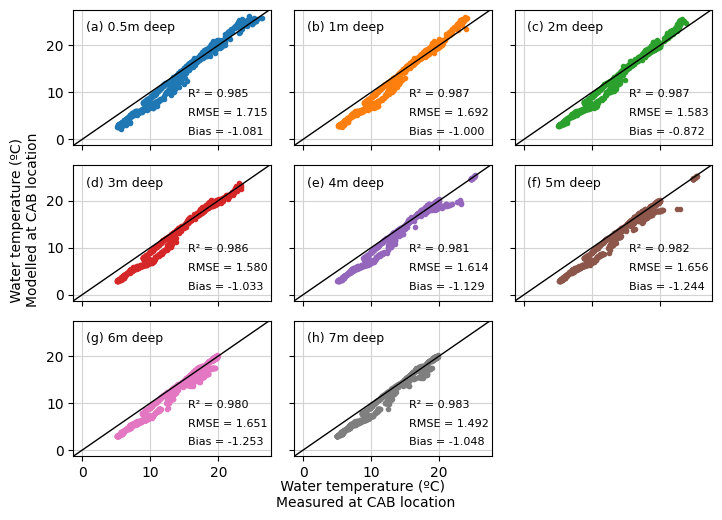

In [62]:
# CAB LOCATION
# Temperature - CAB location
legend = ['(a) 0.5m deep', '(b) 1m deep', '(c) 2m deep', '(d) 3m deep', 
          '(e) 4m deep', '(f) 5m deep', '(g) 6m deep', '(h) 7m deep', 
          '(i) 8m deep', '(j) 9m deep']
WT_CAB_measured = WT_CAB_quant_compare.columns[0:10]
WT_CAB_model = WT_CAB_quant_compare.columns[10:-10]

# Plot graph with measured and modelled water temperature for each depth
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = [7,5], sharey = True, sharex = True)
pal = sns.color_palette("tab10", 10)

for column in range(0, 10, 1):
    if (column < 3):
        ax[0,column].scatter(WT_CAB_quant_compare[WT_CAB_measured[column]], 
                             WT_CAB_quant_compare[WT_CAB_model[column]],
                             marker = '.', label = legend[column], color = pal.as_hex()[column], zorder = 1)
#         ax[0,column].legend(loc = 'upper left', fontsize = 8)
        ax[0,column].text(0.5, 23, legend[column], color = 'k', fontsize = 9)
        ax[0,column].set_axisbelow(True)
        ax[0,column].grid(color='lightgray')
        ax[0,column].text(15.5, 9, 'R² = %0.3f' % r2_list[column], color = 'k', fontsize = 8)
        ax[0,column].text(15.5, 5, 'RMSE = %0.3f' % RMSE_list[column], color = 'k', fontsize = 8)
        ax[0,column].text(15.5, 1, 'Bias = %0.3f' % bias_list[column], color = 'k', fontsize = 8)
        ax[0,column].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)
        
    if (column > 2) & (column < 6):
        ax[1,column-3].scatter(WT_CAB_quant_compare[WT_CAB_measured[column]], 
                               WT_CAB_quant_compare[WT_CAB_model[column]],
                               marker = '.', label = legend[column], color = pal.as_hex()[column], zorder = 1)
        ax[1,column-3].text(0.5, 23, legend[column], color = 'k', fontsize = 9)
        ax[1,column-3].set_axisbelow(True)
        ax[1,column-3].grid(color='lightgray')
        ax[1,column-3].text(15.5, 9, 'R² = %0.3f' % r2_list[column], color = 'k', fontsize = 8)
        ax[1,column-3].text(15.5, 5, 'RMSE = %0.3f' % RMSE_list[column], color = 'k', fontsize = 8)
        ax[1,column-3].text(15.5, 1, 'Bias = %0.3f' % bias_list[column], color = 'k', fontsize = 8)
        ax[1,column-3].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)

    if (column > 5) & (column < 8):
        ax[2,column-6].scatter(WT_CAB_quant_compare[WT_CAB_measured[column]], 
                               WT_CAB_quant_compare[WT_CAB_model[column]],
                               marker = '.', label = legend[column], color = pal.as_hex()[column], zorder = 1)
        ax[2,column-6].text(0.5, 23, legend[column], color = 'k', fontsize = 9)
        ax[2,column-6].set_axisbelow(True)
        ax[2,column-6].grid(color='lightgray')
        ax[2,column-6].text(15.5, 9, 'R² = %0.3f' % r2_list[column], color = 'k', fontsize = 8)
        ax[2,column-6].text(15.5, 5, 'RMSE = %0.3f' % RMSE_list[column], color = 'k', fontsize = 8)
        ax[2,column-6].text(15.5, 1, 'Bias = %0.3f' % bias_list[column], color = 'k', fontsize = 8)
        ax[2,column-6].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)
    if (column == 10):
        ax[3,column-10].scatter(WT_CAB_quant_compare[WT_CAB_measured[column]], 
                               WT_CAB_quant_compare[WT_CAB_model[column]],
                               marker = '.', label = legend[column], color = pal.as_hex()[column], zorder = 1)
        ax[3,column-10].text(0.5, 23, legend[column], color = 'k', fontsize = 9)
        ax[3,column-10].set_axisbelow(True)
        ax[3,column-10].grid(color='lightgray')
#         ax[2,column-9].text(14, 9, 'R² = %0.3f' % r2_list[column], color = 'k', fontsize = 8)
#         ax[2,column-9].text(14, 6, 'RMSE = %0.3f' % RMSE_list[column], color = 'k', fontsize = 8)
#         ax[2,column-9].text(14, 3, 'Bias = %0.3f' % bias_list[column], color = 'k', fontsize = 8)
        ax[3,column-10].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)

fig.text(-0.03, 0.55, ' Water temperature (ºC)'+'\n'+'Modelled at CAB location', va='center', rotation='vertical')
fig.text(0.35, 0, ' Water temperature (ºC)'+'\n'+'Measured at CAB location', va='center', rotation='horizontal')

ax[2,2].axis("off")

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('WT_CAB_scatter_model_measured_mdf15.jpeg', dpi=600, bbox_inches='tight')

plt.show();

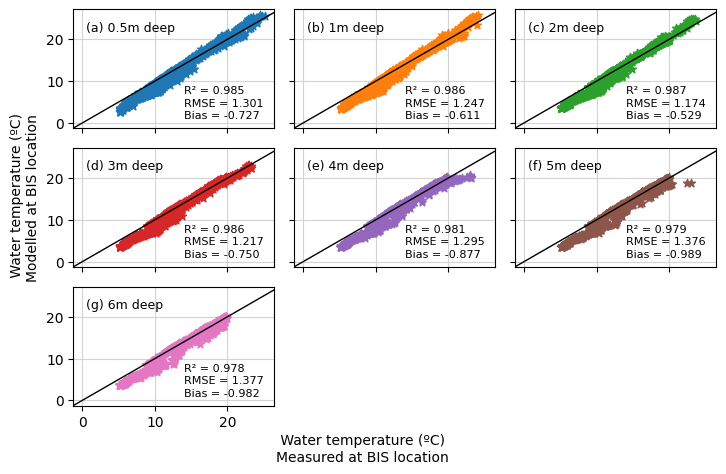

In [78]:
# CAB LOCATION
# Temperature - BIS location
legend = ['(a) 0.5m deep', '(b) 1m deep', '(c) 2m deep', '(d) 3m deep', 
          '(e) 4m deep', '(f) 5m deep', '(g) 6m deep', '(h) 7m deep', 
          '(i) 8m deep', '(j) 9m deep']
WT_BIS_measured = WT_BIS_quant_compare.columns[0:10]
WT_BIS_model = WT_BIS_quant_compare.columns[10:-10]

# Plot graph with measured and modelled water temperature for each depth
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = [7,4.5], sharey = True, sharex = True)
pal = sns.color_palette("tab10", 9)

for column in range(0, 9, 1):
    if (column < 3):
        ax[0,column].scatter(WT_BIS_quant_compare[WT_BIS_measured[column]], 
                             WT_BIS_quant_compare[WT_BIS_model[column]],
                             marker = '*', label = legend[column], color = pal.as_hex()[column], zorder = 1)
#         ax[0,column].legend(loc = 'upper left', fontsize = 8)
        ax[0,column].text(0.5, 22, legend[column], color = 'k', fontsize = 9)
        ax[0,column].set_axisbelow(True)
        ax[0,column].grid(color='lightgray')
        ax[0,column].text(14, 7, 'R² = %0.3f' % r2_list_BIS[column], color = 'k', fontsize = 8)
        ax[0,column].text(14, 4, 'RMSE = %0.3f' % RMSE_list_BIS[column], color = 'k', fontsize = 8)
        ax[0,column].text(14, 1, 'Bias = %0.3f' % bias_list_BIS[column], color = 'k', fontsize = 8)
        ax[0,column].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)
        
    if (column > 2) & (column < 6):
        ax[1,column-3].scatter(WT_BIS_quant_compare[WT_BIS_measured[column]], 
                               WT_BIS_quant_compare[WT_BIS_model[column]],
                               marker = '*', label = legend[column], color = pal.as_hex()[column], zorder = 1)
        ax[1,column-3].text(0.5, 22, legend[column], color = 'k', fontsize = 9)
        ax[1,column-3].set_axisbelow(True)
        ax[1,column-3].grid(color='lightgray')
        ax[1,column-3].text(14, 7, 'R² = %0.3f' % r2_list_BIS[column], color = 'k', fontsize = 8)
        ax[1,column-3].text(14, 4, 'RMSE = %0.3f' % RMSE_list_BIS[column], color = 'k', fontsize = 8)
        ax[1,column-3].text(14, 1, 'Bias = %0.3f' % bias_list_BIS[column], color = 'k', fontsize = 8)
        ax[1,column-3].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)
        
    if (column > 5) & (column <7):
        ax[2,column-6].scatter(WT_BIS_quant_compare[WT_BIS_measured[column]], 
                               WT_BIS_quant_compare[WT_BIS_model[column]],
                               marker = '*', label = legend[column], color = pal.as_hex()[column], zorder = 1)
        ax[2,column-6].text(0.5, 22, legend[column], color = 'k', fontsize = 9)
        ax[2,column-6].set_axisbelow(True)
        ax[2,column-6].grid(color='lightgray')
        ax[2,column-6].text(14, 7, 'R² = %0.3f' % r2_list_BIS[column], color = 'k', fontsize = 8)
        ax[2,column-6].text(14, 4, 'RMSE = %0.3f' % RMSE_list_BIS[column], color = 'k', fontsize = 8)
        ax[2,column-6].text(14, 1, 'Bias = %0.3f' % bias_list_BIS[column], color = 'k', fontsize = 8)
        ax[2,column-6].axline(xy1=(0, 0), slope = 1, color = 'k', lw = 1)

fig.text(-0.03, 0.55, ' Water temperature (ºC)'+'\n'+'Modelled at BIS location', va='center', rotation='vertical')
fig.text(0.35, -0.01, ' Water temperature (ºC)'+'\n'+'Measured at BIS location', va='center', rotation='horizontal')

ax[2,2].axis("off")
ax[2,1].axis("off")

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('WT_BIS_scatter_model_measured_mdf13.jpeg', dpi=600, bbox_inches='tight')

plt.show();

Time series - model x measured

<ipython-input-64-0948e83bd91d>:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[2,0].set_xticklabels(xlabels_new)


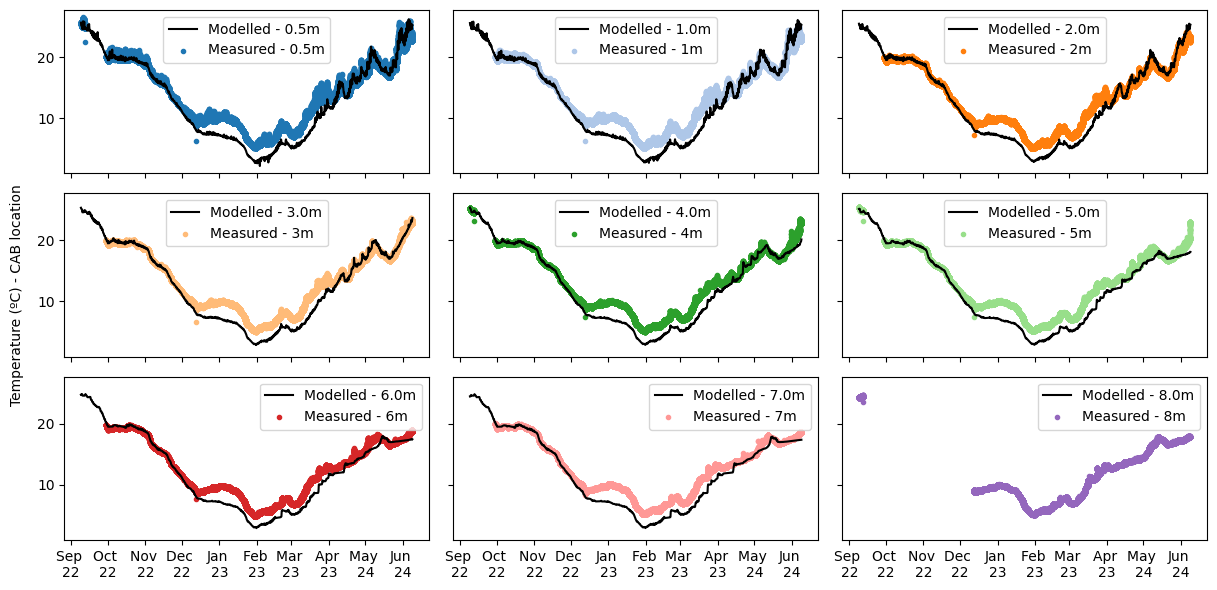

In [64]:
# Temperature - CAB location
WT_CAB_measured_plot = all_data_T.set_index('date_approximate')
legend = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m', '8m', '9m']

# Plot graph with measured and modelled water temperature for each depth
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = [12,6], sharey = True, sharex = True)
pal = sns.color_palette("tab20", 20)

for column in range(0, 10, 1):
    if (column < 3):
         # subset modelled data for certain depth
        temp_model = (model_wt_interp_CAB[model_wt_interp_CAB['depth_from_surface'] == 
                                          (model_wt_interp_CAB['depth_from_surface'].unique()[column])])
        
        ax[0,column].plot(temp_model.index, temp_model[temp_model.columns[1]],
                     linewidth = '1.5', linestyle = '-', label = ('Modelled - ' + str(temp_model.iloc[0,0]) + 'm'), 
                     color = 'k', zorder = 1)
        
        ax[0,column].scatter(WT_CAB_measured_plot.index, WT_CAB_measured_plot[WT_CAB_measured_plot.columns[column]], 
                        marker = '.', label = ('Measured - ' + legend[column]), 
                        color = pal.as_hex()[column], zorder = -1)
        
        ax[0,column].legend()
        
    if (column > 2) & (column < 6):
        # subset modelled data for certain depth
        temp_model = (model_wt_interp_CAB[model_wt_interp_CAB['depth_from_surface'] == 
                                          (model_wt_interp_CAB['depth_from_surface'].unique()[column])])
        
        ax[1,column-3].plot(temp_model.index, temp_model[temp_model.columns[1]],
                     linewidth = '1.5', linestyle = '-', label = ('Modelled - ' + str(temp_model.iloc[0,0]) + 'm'), 
                     color = 'k', zorder = 1)
        
        ax[1,column-3].scatter(WT_CAB_measured_plot.index, WT_CAB_measured_plot[WT_CAB_measured_plot.columns[column]], 
                        marker = '.', label = ('Measured - ' + legend[column]), 
                        color = pal.as_hex()[column], zorder = -1)
        
        ax[1,column-3].legend()
        
    if (column > 5) & (column <9):
        # subset modelled data for certain depth
        temp_model = (model_wt_interp_CAB[model_wt_interp_CAB['depth_from_surface'] == 
                                          (model_wt_interp_CAB['depth_from_surface'].unique()[column])])
        
        ax[2,column-6].plot(temp_model.index, temp_model[temp_model.columns[1]],
                     linewidth = '1.5', linestyle = '-', label = ('Modelled - ' + str(temp_model.iloc[0,0]) + 'm'), 
                     color = 'k', zorder = 1)
        
        ax[2,column-6].scatter(WT_CAB_measured_plot.index, WT_CAB_measured_plot[WT_CAB_measured_plot.columns[column]], 
                        marker = '.', label = ('Measured - ' + legend[column]), 
                        color = pal.as_hex()[column], zorder = -1)
        
        ax[2,column-6].legend()

# Add formatted date labels
xlabels = ['Sep 22','Oct 22', 'Nov 22', 'Dec 22','Jan 23', 'Feb 23', 'Mar 23','Apr 23', 'May 24', 'Jun 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[2,0].set_xticklabels(xlabels_new)

fig.text(-0.01, 0.5, 'Temperature (ºC) - CAB location', va='center', rotation='vertical')
plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('WT_CAB_model_measured_mdf15.jpeg', dpi=600, bbox_inches='tight')

plt.show();

<ipython-input-65-96f49d746767>:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[2,0].set_xticklabels(xlabels_new)


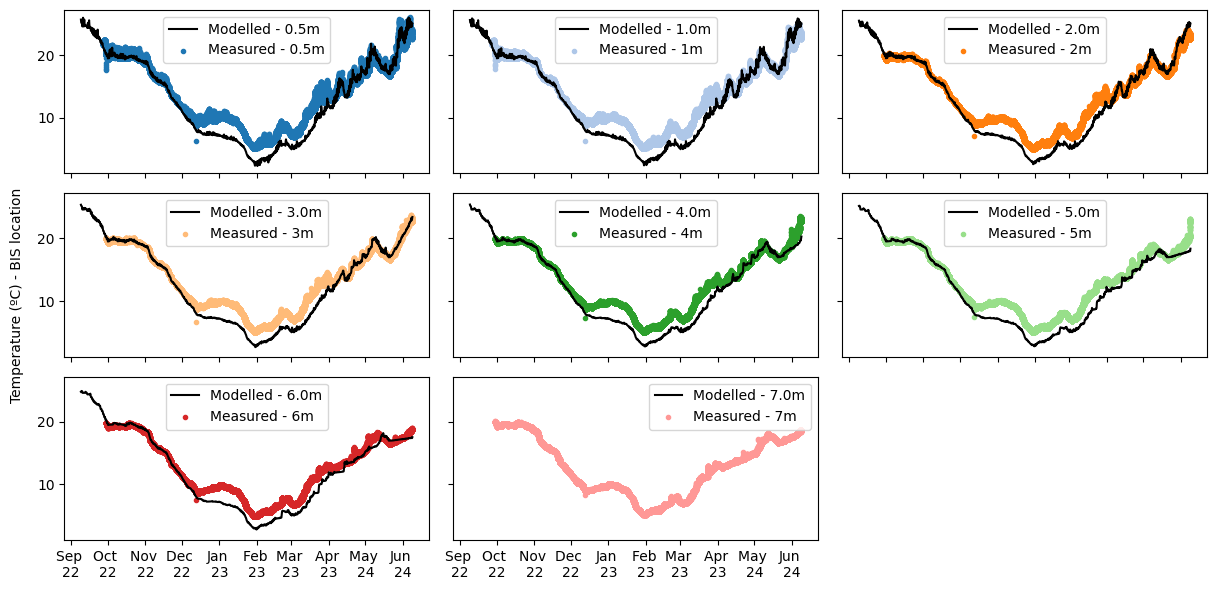

In [65]:
# Temperature
WT_BIS_measured_plot = all_data_T_BIS.set_index('date_approximate')
legend = ['0.5m','1m', '2m', '3m', '4m', '5m', '6m', '7m', '8m', '9m']

# Plot graph with measured and modelled water temperature for each depth
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = [12,6], sharey = True, sharex = True)
pal = sns.color_palette("tab20", 20)

for column in range(0, 8, 1):
    if (column < 3):
         # subset modelled data for certain depth
        temp_model = (model_wt_interp_BIS[model_wt_interp_BIS['depth_from_surface'] == 
                                          (model_wt_interp_BIS['depth_from_surface'].unique()[column])])
        
        ax[0,column].plot(temp_model.index, temp_model[temp_model.columns[1]],
                     linewidth = '1.5', linestyle = '-', label = ('Modelled - ' + str(temp_model.iloc[0,0]) + 'm'), 
                     color = 'k', zorder = 1)
        
        ax[0,column].scatter(WT_BIS_measured_plot.index, WT_BIS_measured_plot[WT_BIS_measured_plot.columns[column]], 
                        marker = '.', label = ('Measured - ' + legend[column]), 
                        color = pal.as_hex()[column], zorder = -1)
        
        ax[0,column].legend()
        
    if (column > 2) & (column < 6):
        # subset modelled data for certain depth
        temp_model = (model_wt_interp_BIS[model_wt_interp_BIS['depth_from_surface'] == 
                                          (model_wt_interp_BIS['depth_from_surface'].unique()[column])])
        
        ax[1,column-3].plot(temp_model.index, temp_model[temp_model.columns[1]],
                     linewidth = '1.5', linestyle = '-', label = ('Modelled - ' + str(temp_model.iloc[0,0]) + 'm'), 
                     color = 'k', zorder = 1)
        
        ax[1,column-3].scatter(WT_BIS_measured_plot.index, WT_BIS_measured_plot[WT_BIS_measured_plot.columns[column]], 
                        marker = '.', label = ('Measured - ' + legend[column]), 
                        color = pal.as_hex()[column], zorder = -1)
        
        ax[1,column-3].legend()
        
    if (column > 5) & (column <8):
        # subset modelled data for certain depth
        temp_model = (model_wt_interp_BIS[model_wt_interp_BIS['depth_from_surface'] == 
                                          (model_wt_interp_BIS['depth_from_surface'].unique()[column])])
        
        ax[2,column-6].plot(temp_model.index, temp_model[temp_model.columns[1]],
                     linewidth = '1.5', linestyle = '-', label = ('Modelled - ' + str(temp_model.iloc[0,0]) + 'm'), 
                     color = 'k', zorder = 1)
        
        ax[2,column-6].scatter(WT_BIS_measured_plot.index, WT_BIS_measured_plot[WT_BIS_measured_plot.columns[column]], 
                        marker = '.', label = ('Measured - ' + legend[column]), 
                        color = pal.as_hex()[column], zorder = -1)
        
        ax[2,column-6].legend()
        
# Add formatted date labels
xlabels = ['Sep 22','Oct 22', 'Nov 22', 'Dec 22','Jan 23', 'Feb 23', 'Mar 23','Apr 23', 'May 24', 'Jun 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[2,0].set_xticklabels(xlabels_new)

ax[2,2].set_axis_off()

fig.text(-0.01, 0.5, 'Temperature (ºC) - BIS location', va='center', rotation='vertical')
plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('WT_BIS_model_measured_mdf15.jpeg', dpi=600, bbox_inches='tight')

plt.show();

# Potential Energy Anomaly

Model output - estimation of PEA for CAB location

In [66]:
# Read files and add columns for each run - CAB LOCATION
for file in range(0,1,1):
    hist_mdf = xr.open_dataset(all_files[file], decode_times = True)
    temporary = hist_mdf[['ZRHO','ZWL']].sel(NOSTAT = 0).to_dataframe()
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time']) # transforms datatype to datetime
    temporary.set_index('time', inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'layer_centre',
                                temporary.columns[1]:('rho_CAB_modelled'),
                                temporary.columns[2]:('depth_CAB_modelled'),
                                temporary.columns[3]:'station_name',
                                temporary.columns[4]:'coord_x',
                                temporary.columns[5]:'coord_y'}, inplace = True)
    temporary['depth_CAB_modelled'] = (temporary['depth_CAB_modelled'] + 14.79)
    temporary = temporary[temporary.columns[0:-3]]
    model_density_CAB = temporary.copy()

model_density_CAB['month'] = model_density_CAB.index.month
model_density_CAB['month_str'] = model_density_CAB['month'].apply(lambda x: calendar.month_abbr[x])
model_density_CAB.drop('month', axis = 1, inplace = True)
model_density_CAB.head(2)

,layer_centre,rho_CAB_modelled,depth_CAB_modelled,month_str
time,,,,
2022-09-09,0,997.598755,8.5,Sep
2022-09-09,1,997.505432,8.5,Sep


In [67]:
# Creates new column with depth
model_density_cab = model_density_CAB.copy()

for timestep in range(0, len(model_density_cab.index.unique()), 1):
    # create copy of modelled water density df at the timestep analysed
    temp = model_density_cab.loc[model_density_cab.index.unique()[timestep]]
    temp = temp[temp['rho_CAB_modelled'] != -999]

    # Gets depth at the timestep analysed
    depth_model = depth_model_CAB01.copy()
    depth_model = depth_model[depth_model.index == (model_density_cab.index.unique()[timestep])]

    # # Creates column with depth at the timestep
    temp['max_depth'] = float(depth_model.iloc[0,1])

    # # Creates column with the corresponding layer thickness 
    temp['layer_thickness'] = temp['layer_centre'].apply(layer_thickness)
    # # Creates column with value of half the thickness of the layer - WT output is at the middle of a layer
    temp['middle_layer'] = (temp['layer_thickness'] / 2)

    # # calculates cummulative water head relative to the bottom
    temp['cum_depth_frombottom'] = temp.loc[:, ('layer_thickness')].cumsum()

    # # creates column with depth from the surface
    depths = []

    for layer in range(0, len(temp['layer_centre']), 1):
        max_depth = (float(temp.iloc[0,2]))
        temp.iloc[-1,7] = max_depth
        half_layer_bottom = float(temp.iloc[0,6])

        if layer == 0:
            # maximum depth minus half the first layer from the bottom up
            depth = (max_depth - half_layer_bottom)
            depths.append(depth)
        elif layer == float(temp.iloc[-1,0]):
            # maximum depth minus cum sum from bottom up divided by two (middle of a cell)
            cum_depth_previous = float(temp.iloc[layer-1,7])
            half_current_layer = ((max_depth - cum_depth_previous) / 2)
            depth = half_current_layer
            depths.append(depth)
        else:
            depth_previous = float(temp.iloc[layer - 1,7])
            half_current_layer = ((float(temp.iloc[layer,7]) - float(temp.iloc[layer-1,7])) / 2)
            # maximum depth minus cum sum from bottom up 
            depth = (max_depth - (depth_previous + half_current_layer))
            depths.append(depth)

    temp['depth_from_surface'] = depths
    temp['max_depth'] = max_depth

    # subsets df with only relevant columns
    temp = temp[['layer_centre','depth_from_surface', 'rho_CAB_modelled', 'month_str', 'max_depth']]
    temp.sort_values(by = ['layer_centre'], ascending = False, inplace = True)

    # Join result to dataframe with control run output for comparison
    if timestep == 0:
        model_density_depths_CAB = temp.copy()
    else:
        model_density_depths_CAB = pd.concat([model_density_depths_CAB, temp])

model_density_depths_CAB['depth_from_surface'] = model_density_depths_CAB['depth_from_surface'].apply(round, args = (2,))
model_density_depths_CAB.head(3)

,layer_centre,depth_from_surface,rho_CAB_modelled,month_str,max_depth
time,,,,,
2022-09-09,8,0.09,997.233459,Sep,8.5
2022-09-09,7,0.64,997.262451,Sep,8.5
2022-09-09,6,1.57,997.288696,Sep,8.5


In [68]:
## Calculates PEA
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

PEA_CAB_modelled = pd.DataFrame(columns = ['time', 'PEA_CAB_modelled'])
model_output_CAB = model_density_depths_CAB[['layer_centre', 'depth_from_surface', 
                                             'month_str', 'rho_CAB_modelled', 'max_depth']]
days_CAB = model_output_CAB.index.unique()

for day in range(0, len(days_CAB), 1):
    temporary = model_output_CAB.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_CAB[day]]
    # calculates modelled layer depth
    temporary['delta_depth'] = temporary['depth_from_surface'].diff()
    # takes out na rows from depth diff
    temporary = temporary[temporary['delta_depth'].isna() == False]
    # excludes inactive layers
    temporary = temporary[temporary[('rho_CAB_modelled')] != -999]
    # estimates weight-averaged density for the water column
    mean_rho = ((temporary['rho_CAB_modelled'] * 
                 temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
    # PEA calculation
    temporary['to_sum'] = ((mean_rho - temporary['rho_CAB_modelled']) *
                           g * temporary['depth_from_surface'] * temporary['delta_depth'])
    PEA = (- 1 / (temporary.iloc[-1,4])) * (temporary['to_sum'].sum())
    # creates a new df with time and PEA
    temp_df = pd.DataFrame([temporary.index[0], PEA]).T
    temp_df.rename(columns = 
                   {temp_df.columns[0]:'time', 
                    temp_df.columns[1]:'PEA_CAB_modelled'}, inplace = True)
    # concatenates estimated PEA's into one df
    if day == 0:
        PEA_CAB_modelled = temp_df
    else:
        PEA_CAB_modelled = pd.concat([PEA_CAB_modelled, temp_df])

PEA_CAB_modelled.set_index('time', inplace = True)

# Creates columns with month
PEA_CAB_modelled['month'] = PEA_CAB_modelled.index.month
PEA_CAB_modelled['month_str'] = PEA_CAB_modelled['month'].apply(lambda x: calendar.month_abbr[x])
PEA_CAB_modelled.head(2)

,PEA_CAB_modelled,month,month_str
time,,,
2022-09-09 00:00:00,2.120779,9,Sep
2022-09-09 06:00:00,1.392799,9,Sep


<Axes: xlabel='time'>

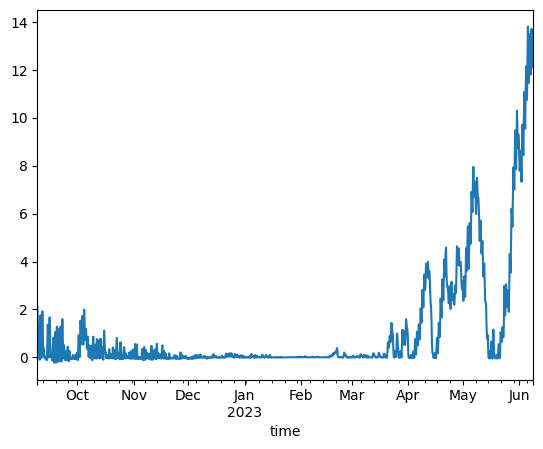

In [69]:
PEA_CAB_modelled['PEA_CAB_modelled'].plot()

In [77]:
# Export PEA time series for changepoint analysis
PEA_CAB_modelled.to_csv('PEA_CAB_modelled_CAB.csv')

Model output - estimation of PEA for BIS location

In [70]:
# Read files and add columns for each run - CAB LOCATION
for file in range(0,1,1):
    hist_mdf = xr.open_dataset(all_files[file], decode_times = True)
    temporary = hist_mdf[['ZRHO','ZWL']].sel(NOSTAT = 1).to_dataframe()
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time']) # transforms datatype to datetime
    temporary.set_index('time', inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'layer_centre',
                                temporary.columns[1]:('rho_BIS_modelled'),
                                temporary.columns[2]:('depth_BIS_modelled'),
                                temporary.columns[3]:'station_name',
                                temporary.columns[4]:'coord_x',
                                temporary.columns[5]:'coord_y'}, inplace = True)
    temporary['depth_BIS_modelled'] = (temporary['depth_BIS_modelled'] + 14.79)
    temporary = temporary[temporary.columns[0:-3]]
    model_density_BIS = temporary.copy()

model_density_BIS['month'] = model_density_BIS.index.month
model_density_BIS['month_str'] = model_density_BIS['month'].apply(lambda x: calendar.month_abbr[x])
model_density_BIS.drop('month', axis = 1, inplace = True)
model_density_BIS.head(2)

,layer_centre,rho_BIS_modelled,depth_BIS_modelled,month_str
time,,,,
2022-09-09,0,997.598755,8.5,Sep
2022-09-09,1,997.505432,8.5,Sep


In [71]:
# Creates new column with depth
model_density_bis = model_density_BIS.copy()

for timestep in range(0, len(model_density_bis.index.unique()), 1):
    # create copy of modelled water density df at the timestep analysed
    temp = model_density_bis.loc[model_density_bis.index.unique()[timestep]]
    temp = temp[temp['rho_BIS_modelled'] != -999]

    # Gets depth at the timestep analysed
    depth_model = depth_model_BIS.copy()
    depth_model = depth_model[depth_model.index == (model_density_bis.index.unique()[timestep])]

    # # Creates column with depth at the timestep
    temp['max_depth'] = float(depth_model.iloc[0,1])

    # # Creates column with the corresponding layer thickness 
    temp['layer_thickness'] = temp['layer_centre'].apply(layer_thickness)
    # # Creates column with value of half the thickness of the layer - WT output is at the middle of a layer
    temp['middle_layer'] = (temp['layer_thickness'] / 2)

    # # calculates cummulative water head relative to the bottom
    temp['cum_depth_frombottom'] = temp.loc[:, ('layer_thickness')].cumsum()

    # # creates column with depth from the surface
    depths = []

    for layer in range(0, len(temp['layer_centre']), 1):
        max_depth = (float(temp.iloc[0,2]))
        temp.iloc[-1,7] = max_depth
        half_layer_bottom = float(temp.iloc[0,6])

        if layer == 0:
            # maximum depth minus half the first layer from the bottom up
            depth = (max_depth - half_layer_bottom)
            depths.append(depth)
        elif layer == float(temp.iloc[-1,0]):
            # maximum depth minus cum sum from bottom up divided by two (middle of a cell)
            cum_depth_previous = float(temp.iloc[layer-1,7])
            half_current_layer = ((max_depth - cum_depth_previous) / 2)
            depth = half_current_layer
            depths.append(depth)
        else:
            depth_previous = float(temp.iloc[layer - 1,7])
            half_current_layer = ((float(temp.iloc[layer,7]) - float(temp.iloc[layer-1,7])) / 2)
            # maximum depth minus cum sum from bottom up 
            depth = (max_depth - (depth_previous + half_current_layer))
            depths.append(depth)

    temp['depth_from_surface'] = depths
    temp['max_depth'] = max_depth

    # subsets df with only relevant columns
    temp = temp[['layer_centre','depth_from_surface', 'rho_BIS_modelled', 'month_str', 'max_depth']]
    temp.sort_values(by = ['layer_centre'], ascending = False, inplace = True)

    # Join result to dataframe with control run output for comparison
    if timestep == 0:
        model_density_depths_BIS = temp.copy()
    else:
        model_density_depths_BIS = pd.concat([model_density_depths_BIS, temp])

model_density_depths_BIS['depth_from_surface'] = model_density_depths_BIS['depth_from_surface'].apply(round, args = (2,))
model_density_depths_BIS.head(3)

,layer_centre,depth_from_surface,rho_BIS_modelled,month_str,max_depth
time,,,,,
2022-09-09,8,0.09,997.233459,Sep,8.5
2022-09-09,7,0.64,997.262451,Sep,8.5
2022-09-09,6,1.57,997.288696,Sep,8.5


In [72]:
## Calculates PEA
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

model_output_CAB = model_density_depths_BIS[['layer_centre', 'depth_from_surface', 
                                             'month_str', 'rho_BIS_modelled', 'max_depth']]
days_CAB = model_output_CAB.index.unique()

for day in range(0, len(days_CAB), 1):
    temporary = model_output_CAB.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_CAB[day]]
    # calculates modelled layer depth
    temporary['delta_depth'] = temporary['depth_from_surface'].diff()
    # takes out na rows from depth diff
    temporary = temporary[temporary['delta_depth'].isna() == False]
    # excludes inactive layers
    temporary = temporary[temporary[('rho_BIS_modelled')] != -999]
    # estimates weight-averaged density for the water column
    mean_rho = ((temporary['rho_BIS_modelled'] * 
                 temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
    # PEA calculation
    temporary['to_sum'] = ((mean_rho - temporary['rho_BIS_modelled']) *
                           g * temporary['depth_from_surface'] * temporary['delta_depth'])
    PEA = (- 1 / (temporary.iloc[-1,4])) * (temporary['to_sum'].sum())
    # creates a new df with time and PEA
    temp_df = pd.DataFrame([temporary.index[0], PEA]).T
    temp_df.rename(columns = 
                   {temp_df.columns[0]:'time', 
                    temp_df.columns[1]:'PEA_BIS_modelled'}, inplace = True)
    # concatenates estimated PEA's into one df
    if day == 0:
        PEA_BIS_modelled = temp_df
    else:
        PEA_BIS_modelled = pd.concat([PEA_BIS_modelled, temp_df])

PEA_BIS_modelled.set_index('time', inplace = True)

# Creates columns with month
PEA_BIS_modelled['month'] = PEA_BIS_modelled.index.month
PEA_BIS_modelled['month_str'] = PEA_BIS_modelled['month'].apply(lambda x: calendar.month_abbr[x])
PEA_BIS_modelled.head(2)

,PEA_BIS_modelled,month,month_str
time,,,
2022-09-09 00:00:00,2.120779,9,Sep
2022-09-09 06:00:00,1.353014,9,Sep


<Axes: xlabel='time'>

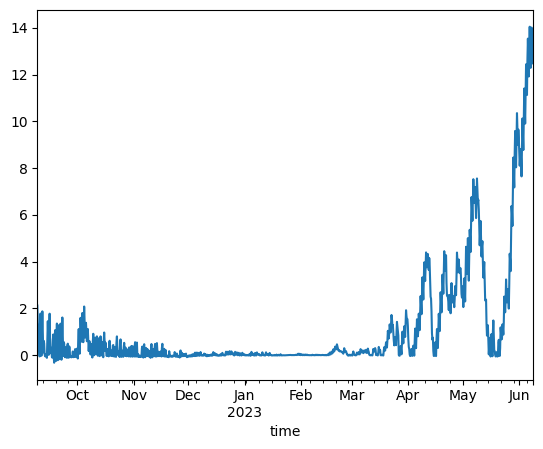

In [74]:
PEA_BIS_modelled['PEA_BIS_modelled'].plot()

In [82]:
# Export PEA time series for changepoint analysis
PEA_BIS_modelled.to_csv('PEA_BIS_modelled.csv')

# PEA Measurements

In [73]:
# Create df with model timesteps to join with measurements - makes the code more efficient
time_model = pd.DataFrame(PEA_CAB_modelled.index)
time_model.set_index('time', inplace = True)
time_model.head(2)

""
time
2022-09-09 00:00:00
2022-09-09 06:00:00


CAB LOCATION

In [74]:
## Calculate density from temperature measurements - UNESCO formulation
salinity = 0.5

# Prepare dataframe
density_CAB_field = all_data_T.copy()
density_CAB_field.rename(columns = {'date_approximate':'time'}, inplace = True)
density_CAB_field.set_index('time', inplace = True)
density_CAB_field = time_model.merge(density_CAB_field, on = 'time', how = 'left')

for depth in (density_CAB_field.columns):
    temp_rho_CAB = pd.DataFrame(density_CAB_field[depth])
    # UNESCO formulation to estimate density: rho = rho0 + As + Bs^(1.5) + (Cs)²
    temp_rho_CAB['rho0_' + depth[6:] + '_m'] = (999.842594 + 
                                                (6.793952 * 0.01 * temp_rho_CAB[temp_rho_CAB.columns[0]]) -
                                                (9.095290 * 0.001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)) +
                                                (1.001685 * 0.0001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 3)) -
                                                (1.120083 * 0.000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 4)) +
                                                (6.536332 * 0.000000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 5)))

    temp_rho_CAB['A_' + depth[6:] + '_m'] = (8.24493 * 0.1 - 
                                             (4.0899 * 0.001 * (temp_rho_CAB[temp_rho_CAB.columns[0]])) +
                                             (7.6438 * 0.00001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)) -
                                             (8.2467 * 0.0000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 3)) +
                                             (5.3875 * 0.000000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 4)))

    temp_rho_CAB['B_' + depth[6:] + '_m'] = (((-5.72466) * 0.001) + 
                                             (1.0227 * 0.0001 * (temp_rho_CAB[temp_rho_CAB.columns[0]])) -
                                             (1.6546 * 0.000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)))

    temp_rho_CAB['C_' + depth[6:] + '_m'] = (4.8314 * 0.0001)

    temp_rho_CAB['rho_' + depth[6:] + '_m'] = ((temp_rho_CAB['rho0_' + depth[6:] + '_m']) +
                                               ((temp_rho_CAB['A_' + depth[6:] + '_m']) * salinity) + 
                                               ((temp_rho_CAB['B_' + depth[6:] + '_m']) * (salinity ** (3 / 2))) +
                                               ((temp_rho_CAB['C_' + depth[6:] + '_m']) * (salinity ** 2)))

    temp_rho_CAB = temp_rho_CAB[[depth, 'rho_' + depth[6:] + '_m']]
    temp_rho_CAB = pd.DataFrame(temp_rho_CAB[temp_rho_CAB.columns[-1]])
    if depth == density_CAB_field.columns[0]:
        rho_measured_CAB = pd.DataFrame(temp_rho_CAB[temp_rho_CAB.columns[-1]])
    else:
        rho_measured_CAB = pd.concat([rho_measured_CAB, temp_rho_CAB], axis=1)

rho_measured_CAB.head(3)

,rho_0_m,rho_1_m,rho_2_m,rho_3_m,rho_4_m,rho_5_m,rho_7_m,rho_8_m,rho_9_m,rho_6_m
time,,,,,,,,,,
2022-09-09 00:00:00,997.233460,NaN,NaN,NaN,997.346093,997.312225,NaN,NaN,997.598755,NaN
2022-09-09 06:00:00,997.325270,NaN,NaN,NaN,997.356482,997.325270,NaN,NaN,997.608767,NaN
2022-09-09 12:00:00,997.301771,NaN,NaN,NaN,997.379802,997.335689,NaN,NaN,997.588728,NaN


In [85]:
rho_measured_CAB.to_csv('rho_measured_CAB.csv')

In [75]:
## Calculates PEA for CAB location (measurements)
# Loop does calculations for every day and time from model output
g = 9.81

PEA_CAB_measured_ts = pd.DataFrame(columns = ['time', 'PEA_CAB_measured'])
days_CAB_measured = rho_measured_CAB.index.unique()

for day in range(0, len(days_CAB_measured), 1):
    temporary = rho_measured_CAB.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_CAB_measured[day]] 
    temporary.reset_index(inplace = True)
    # Transposes to get depths in rows (not columns)
    temporary = temporary.T
    # Creates column with timestep analysed to store info
    temporary['time'] = temporary[temporary.columns[0]][0]
    # Drops first row (timestep)
    temporary = temporary.iloc[1:]
    # Removes nas from series
    temporary.dropna(inplace = True)
    ## Estimates layer depths
    # Gets depth per row
    temporary['depth_result'] = temporary.index.str[4:-2].astype('float64')
    # Replaces 0m by 0.5m which is the correct measurement depth
    temporary.replace(0.0, 0.5, inplace=True)
    # Calculates the layer depth
    temporary['delta_depth'] = temporary['depth_result'].diff()
    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'id',
                                temporary.columns[1]:'rho_measured'}, inplace = True)
    temporary.set_index('time', inplace = True)
    if (temporary['delta_depth'].sum()) == 0:
        pass
    else:
        # estimates weight-averaged density for the water column
        mean_rho = ((temporary['rho_measured'] * temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
        # PEA calculation
        temporary['to_sum'] = ((mean_rho - temporary['rho_measured']) * g * temporary['depth_result'] * 
                               temporary['delta_depth'])
        PEA = (1 / -(temporary.iloc[-1,2])) * (temporary['to_sum'].sum()) # the result from iloc is the total depth

        # creates a new df with time and PEA
        temp_df = pd.DataFrame([temporary.index[0], PEA]).T
        temp_df.rename(columns = {temp_df.columns[0]:'time', 
                                  temp_df.columns[1]:'PEA_CAB_measured'}, inplace = True)
        # concatenates estimated PEA's for full simulation period
        PEA_CAB_measured_ts = pd.concat([PEA_CAB_measured_ts, temp_df])

# Creates columns with month
PEA_CAB_measured_ts['month'] = PEA_CAB_measured_ts['time'].dt.month
PEA_CAB_measured_ts['month_str'] = PEA_CAB_measured_ts['month'].apply(lambda x: calendar.month_abbr[x])

PEA_CAB_measured_ts.set_index('time', inplace = True)
PEA_CAB_measured_ts.head(2)

,PEA_CAB_measured,month,month_str
time,,,
2022-09-09 00:00:00,2.840705,9,Sep
2022-09-09 06:00:00,2.832287,9,Sep


BIS LOCATION

In [76]:
## Calculate density from temperature measurements - UNESCO formulation
salinity = 0.5

# Prepare dataframe
density_BIS_field = all_data_T_BIS.copy()
density_BIS_field.rename(columns = {'date_approximate':'time'}, inplace = True)
density_BIS_field.set_index('time', inplace = True)
density_BIS_field = time_model.merge(density_BIS_field, on = 'time', how = 'left')

for depth in (density_BIS_field.columns):
    temp_rho_BIS = pd.DataFrame(density_BIS_field[depth])
    # UNESCO formulation to estimate density: rho = rho0 + As + Bs^(1.5) + (Cs)²
    temp_rho_BIS['rho0_' + depth[6:] + '_m'] = (999.842594 + 
                                                (6.793952 * 0.01 * temp_rho_BIS[temp_rho_BIS.columns[0]]) -
                                                (9.095290 * 0.001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 2)) +
                                                (1.001685 * 0.0001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 3)) -
                                                (1.120083 * 0.000001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 4)) +
                                                (6.536332 * 0.000000001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 5)))

    temp_rho_BIS['A_' + depth[6:] + '_m'] = (8.24493 * 0.1 - 
                                             (4.0899 * 0.001 * (temp_rho_BIS[temp_rho_BIS.columns[0]])) +
                                             (7.6438 * 0.00001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 2)) -
                                             (8.2467 * 0.0000001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 3)) +
                                             (5.3875 * 0.000000001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 4)))

    temp_rho_BIS['B_' + depth[6:] + '_m'] = (((-5.72466) * 0.001) + 
                                             (1.0227 * 0.0001 * (temp_rho_BIS[temp_rho_BIS.columns[0]])) -
                                             (1.6546 * 0.000001 * ((temp_rho_BIS[temp_rho_BIS.columns[0]]) ** 2)))

    temp_rho_BIS['C_' + depth[6:] + '_m'] = (4.8314 * 0.0001)

    temp_rho_BIS['rho_' + depth[6:] + '_m'] = ((temp_rho_BIS['rho0_' + depth[6:] + '_m']) +
                                               ((temp_rho_BIS['A_' + depth[6:] + '_m']) * salinity) + 
                                               ((temp_rho_BIS['B_' + depth[6:] + '_m']) * (salinity ** (3 / 2))) +
                                               ((temp_rho_BIS['C_' + depth[6:] + '_m']) * (salinity ** 2)))

    temp_rho_BIS = temp_rho_BIS[[depth, 'rho_' + depth[6:] + '_m']]
    temp_rho_BIS = pd.DataFrame(temp_rho_BIS[temp_rho_BIS.columns[-1]])
    
    if depth == density_BIS_field.columns[0]:
        rho_measured_BIS = pd.DataFrame(temp_rho_BIS[temp_rho_BIS.columns[-1]])
    else:
        rho_measured_BIS = pd.concat([rho_measured_BIS, temp_rho_BIS], axis=1)

rho_measured_BIS.head(3)

,rho_0_m,rho_1_m,rho_2_m,rho_3_m,rho_4_m,rho_5_m,rho_7_m,rho_8_m,rho_9_m,rho_6_m
time,,,,,,,,,,
2022-09-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-09 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-09 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
## Calculates PEA for CAB location (measurements)
# Loop does calculations for every day and time from model output
g = 9.81

PEA_BIS_measured_ts = pd.DataFrame(columns = ['time', 'PEA_BIS_measured'])
days_BIS_measured = rho_measured_BIS.index.unique()

for day in range(0, len(days_BIS_measured), 1):
    temporary = rho_measured_BIS.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_BIS_measured[day]] 
    temporary.reset_index(inplace = True)
    # Transposes to get depths in rows (not columns)
    temporary = temporary.T
    # Creates column with timestep analysed to store info
    temporary['time'] = temporary[temporary.columns[0]][0]
    # Drops first row (timestep)
    temporary = temporary.iloc[1:]
    # Removes nas from series
    temporary.dropna(inplace = True)
    ## Estimates layer depths
    # Gets depth per row
    temporary['depth_result'] = temporary.index.str[4:-2].astype('float64')
    # Replaces 0m by 0.5m which is the correct measurement depth
    temporary.replace(0.0, 0.5, inplace=True)
    # Calculates the layer depth
    temporary['delta_depth'] = temporary['depth_result'].diff()
    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'id',
                                temporary.columns[1]:'rho_measured'}, inplace = True)
    temporary.set_index('time', inplace = True)
    if (temporary['delta_depth'].sum()) == 0:
        pass
    else:
        # estimates weight-averaged density for the water column
        mean_rho = ((temporary['rho_measured'] * temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
        # PEA calculation
        temporary['to_sum'] = ((mean_rho - temporary['rho_measured']) * g * temporary['depth_result'] * 
                               temporary['delta_depth'])
        PEA = (1 / -(temporary.iloc[-1,2])) * (temporary['to_sum'].sum()) # the result from iloc is the total depth

        # creates a new df with time and PEA
        temp_df = pd.DataFrame([temporary.index[0], PEA]).T
        temp_df.rename(columns = {temp_df.columns[0]:'time', 
                                  temp_df.columns[1]:'PEA_BIS_measured'}, inplace = True)
        # concatenates estimated PEA's for full simulation period
        PEA_BIS_measured_ts = pd.concat([PEA_BIS_measured_ts, temp_df])

# Creates columns with month
PEA_BIS_measured_ts['month'] = PEA_BIS_measured_ts['time'].dt.month
PEA_BIS_measured_ts['month_str'] = PEA_BIS_measured_ts['month'].apply(lambda x: calendar.month_abbr[x])

PEA_BIS_measured_ts.set_index('time', inplace = True)
PEA_BIS_measured_ts.head(2)

,PEA_BIS_measured,month,month_str
time,,,
2022-09-27 00:00:00,-0.0,9,Sep
2022-09-27 06:00:00,-0.0,9,Sep


# Density plots - testing equation

In [89]:
density_tests = all_data_T.copy()
density_tests.rename(columns = {'date_approximate':'time'}, inplace = True)
density_tests.set_index('time', inplace = True)
density_tests = time_model.merge(density_tests, on = 'time', how = 'left')
density_tests = pd.DataFrame(density_tests['T_CAB_0'])
density_tests.head(2)

,T_CAB_0
time,
2022-09-09 00:00:00,25.74
2022-09-09 06:00:00,25.39


In [90]:
temp_rho_CAB

,rho_6_m
time,
2022-09-09 00:00:00,NaN
2022-09-09 06:00:00,NaN
2022-09-09 12:00:00,NaN
2022-09-09 18:00:00,NaN
2022-09-10 00:00:00,NaN
...,...
2023-06-07 18:00:00,998.734729
2023-06-08 00:00:00,998.734729
2023-06-08 06:00:00,998.734729


In [91]:
s = 0.4
temp_rho_CAB = density_tests.copy()
# UNESCO formulation to estimate density: rho = rho0 + As + Bs^(1.5) + (Cs)²
temp_rho_CAB['rho0_' + str(s)] = ( 999.842594 + 
                                  (6.793952 * 0.01 * temp_rho_CAB[temp_rho_CAB.columns[0]]) -
                                  (9.095290 * 0.001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)) +
                                  (1.001685 * 0.0001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 3)) -
                                  (1.120083 * 0.000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 4)) +
                                  (6.536332 * 0.000000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 5)))

temp_rho_CAB['A_' + str(s)] = (8.24493 * 0.1 - 
                               (4.0899 * 0.001 * (temp_rho_CAB[temp_rho_CAB.columns[0]])) +
                               (7.6438 * 0.00001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)) -
                               (8.2467 * 0.0000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 3)) +
                               (5.3875 * 0.000000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 4)))

temp_rho_CAB['B_' + str(s)] = (((-5.72466) * 0.001) + 
                               (1.0227 * 0.0001 * (temp_rho_CAB[temp_rho_CAB.columns[0]])) -
                               (1.6546 * 0.000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)))

temp_rho_CAB['C_' + str(s)] = (4.8314 * 0.0001)

temp_rho_CAB['rho'] = ((temp_rho_CAB['rho0_' + str(s)]) +
                       ((temp_rho_CAB['A_' + str(s)]) * s) + 
                       ((temp_rho_CAB['B_' + str(s)]) * (s ** (3 / 2))) +
                       ((temp_rho_CAB['C_' + str(s)]) * (s ** 2)))

temp_rho_CAB = pd.DataFrame(temp_rho_CAB[temp_rho_CAB.columns[-1]])
temp_rho_CAB['salinity'] = s
temp_rho_CAB

,rho,salinity
time,,
2022-09-09 00:00:00,997.158021,0.4
2022-09-09 06:00:00,997.249781,0.4
2022-09-09 12:00:00,997.226296,0.4
2022-09-09 18:00:00,997.249781,0.4
2022-09-10 00:00:00,997.327514,0.4
...,...,...
2023-06-07 18:00:00,997.729013,0.4
2023-06-08 00:00:00,997.866913,0.4
2023-06-08 06:00:00,997.911919,0.4


In [92]:
## Calculate density from temperature measurements - UNESCO formulation
salinity = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

# Prepare dataframe
density_tests = all_data_T.copy()
density_tests.rename(columns = {'date_approximate':'time'}, inplace = True)
density_tests.set_index('time', inplace = True)
density_tests = time_model.merge(density_tests, on = 'time', how = 'left')
density_tests = pd.DataFrame(density_tests['T_CAB_0'])

for s in salinity:
    temp_rho_CAB = density_tests
    # UNESCO formulation to estimate density: rho = rho0 + As + Bs^(1.5) + (Cs)²
    temp_rho_CAB['rho0_' + str(s)] = ( 999.842594 + 
                                      (6.793952 * 0.01 * temp_rho_CAB[temp_rho_CAB.columns[0]]) -
                                      (9.095290 * 0.001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)) +
                                      (1.001685 * 0.0001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 3)) -
                                      (1.120083 * 0.000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 4)) +
                                      (6.536332 * 0.000000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 5)))

    temp_rho_CAB['A_' + str(s)] = (8.24493 * 0.1 - 
                                   (4.0899 * 0.001 * (temp_rho_CAB[temp_rho_CAB.columns[0]])) +
                                   (7.6438 * 0.00001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)) -
                                   (8.2467 * 0.0000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 3)) +
                                   (5.3875 * 0.000000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 4)))

    temp_rho_CAB['B_' + str(s)] = (((-5.72466) * 0.001) + 
                                   (1.0227 * 0.0001 * (temp_rho_CAB[temp_rho_CAB.columns[0]])) -
                                   (1.6546 * 0.000001 * ((temp_rho_CAB[temp_rho_CAB.columns[0]]) ** 2)))

    temp_rho_CAB['C_' + str(s)] = (4.8314 * 0.0001)

    temp_rho_CAB['rho_' + str(s)] = ((temp_rho_CAB['rho0_' + str(s)]) +
                                     ((temp_rho_CAB['A_' + str(s)]) * s) + 
                                     ((temp_rho_CAB['B_' + str(s)]) * (s ** (3 / 2))) +
                                     ((temp_rho_CAB['C_' + str(s)]) * (s ** 2)))

    temp_rho_CAB = pd.DataFrame(temp_rho_CAB[temp_rho_CAB.columns[-1]])
    if (s == 0.2):
        rho_tests = pd.DataFrame(temp_rho_CAB[temp_rho_CAB.columns[-1]])
    else:
        rho_tests = pd.concat([rho_tests, temp_rho_CAB], axis=1)

rho_tests.head(3)

,rho_0.2,rho_0.25,rho_0.3,rho_0.35,rho_0.4,rho_0.45,rho_0.5,rho_0.55,rho_0.6
time,,,,,,,,,
2022-09-09 00:00:00,997.007016,997.044786,997.082543,997.120287,997.158021,997.195745,997.233460,997.271166,997.308864
2022-09-09 06:00:00,997.098676,997.136471,997.174253,997.212022,997.249781,997.287530,997.325270,997.363000,997.400723
2022-09-09 12:00:00,997.075216,997.113005,997.150780,997.188544,997.226296,997.264038,997.301771,997.339496,997.377212


In [93]:
str(salinity)[2:3]

'.'

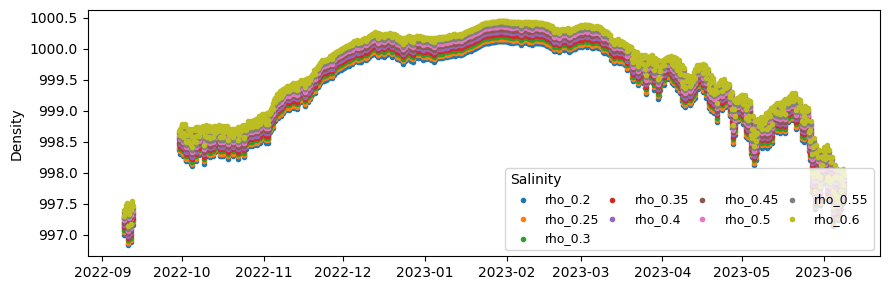

In [94]:
# Plot model x measured for depth
# Plot time series - hourly data
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3], sharex = False, sharey = False)

pal = sns.color_palette("tab10", 10) # set color range

for salinity in range(0, len(rho_tests.columns), 1):
    ax.scatter(rho_tests.index, rho_tests[rho_tests.columns[salinity]], marker = '.', 
           label = rho_tests.columns[salinity], color = pal.as_hex()[salinity])

ax.yaxis.set_label_text('Density', size = 10)

# ax.text(19350, 1.4, 'Bias = %0.3f' % bias_PEA_CAB, color = 'k', fontsize = 10)

# Add legends
ax.legend(title = "Salinity", loc="lower right", ncol = 4, fontsize = 9, 
               frameon = True, columnspacing = 0.01)._legend_box.align = "left"

# ax.set_ylim(7,10)

# Plot settings
# fig.text(-0.01, 0.5, 'Temperature (ºC)', va = 'center', rotation = 'vertical')
# fig.subplots_adjust(top = 0.94)

plt.tight_layout()

# Save graph;
# plt.savefig('WL_model_measured.jpeg', dpi=300)

plt.show();

In [95]:
# Melt data for boxplot
rho_tests_melt = pd.melt(rho_tests)

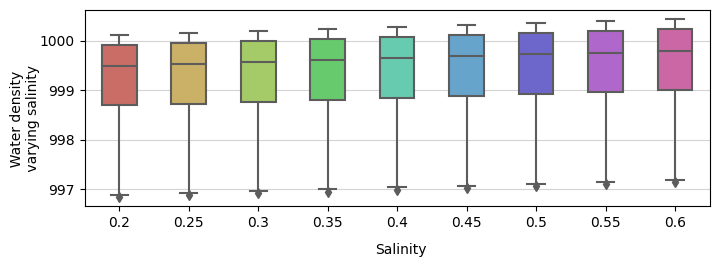

In [96]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [7,2.5])
pal = sns.color_palette("hls", 9)

# CAB Location
sns.boxplot(x = "variable", y = "value", 
            data = rho_tests_melt, width = 0.5, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax)
ax.xaxis.set_label_text("")
ax.yaxis.set_label_text('')

ax.set_xticks([0,1,2,3,4,5,6,7,8], [(rho_tests.columns[0])[4:8], (rho_tests.columns[1])[4:8],
                                    (rho_tests.columns[2])[4:8], (rho_tests.columns[3])[4:8],
                                    (rho_tests.columns[4])[4:8], (rho_tests.columns[5])[4:8],
                                    (rho_tests.columns[6])[4:8], (rho_tests.columns[7])[4:8],
                                    (rho_tests.columns[8])[4:8]])
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

# General plot configurations
plt.subplots_adjust(wspace = 0, hspace = 0)
fig.text(-0.021, 0.5, u'  Water density\n varying salinity', va='center', rotation='vertical')
fig.text(0.5, -0.021, u'Salinity', va='center')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('bias_WT_boxplots.jpeg', dpi=600, bbox_inches='tight')

plt.show();

# Metrics - PEA

CAB LOCATION

In [78]:
# Create joined df to compare data
joined_df_PEA_CAB = pd.DataFrame(PEA_CAB_modelled['PEA_CAB_modelled'])
joined_df_PEA_CAB = joined_df_PEA_CAB.merge(PEA_CAB_measured_ts, on = 'time')
# Change column values to integers
joined_df_PEA_CAB = joined_df_PEA_CAB.astype({'PEA_CAB_modelled': float, 'PEA_CAB_measured': float})

joined_df_PEA_CAB.head(2)

,PEA_CAB_modelled,PEA_CAB_measured,month,month_str
time,,,,
2022-09-09 00:00:00,2.120779,2.840705,9,Sep
2022-09-09 06:00:00,1.392799,2.832287,9,Sep


In [79]:
# Calculates metrics for each depth
n = len(joined_df_PEA_CAB)
r2_PEA_CAB = ((np.corrcoef(joined_df_PEA_CAB[joined_df_PEA_CAB.columns[0]], joined_df_PEA_CAB[joined_df_PEA_CAB.columns[1]])[0,1]) ** 2)
joined_df_PEA_CAB['sq_error'] = ((joined_df_PEA_CAB[joined_df_PEA_CAB.columns[0]] - 
                                  joined_df_PEA_CAB[joined_df_PEA_CAB.columns[1]]) ** 2)
RMSE_PEA_CAB = (((1/n) * (joined_df_PEA_CAB['sq_error'].sum()) ) ** 0.5)
bias_PEA_CAB = (((joined_df_PEA_CAB[joined_df_PEA_CAB.columns[1]] - 
          joined_df_PEA_CAB[joined_df_PEA_CAB.columns[0]]).sum()) / n)

print('r²:', r2_PEA_CAB)
print('')
print('RMSE:', RMSE_PEA_CAB)
print('')
print('Bias:', bias_PEA_CAB)

r²: 0.9498941410146978

RMSE: 0.733559153452941

Bias: 0.34438046764765434


BIS LOCATION

In [80]:
# Create joined df to compare data
joined_df_PEA_BIS = pd.DataFrame(PEA_BIS_modelled['PEA_BIS_modelled'])
joined_df_PEA_BIS = joined_df_PEA_BIS.merge(PEA_BIS_measured_ts, on = 'time')
# Change column values to integers
joined_df_PEA_BIS = joined_df_PEA_BIS.astype({'PEA_BIS_modelled': float, 'PEA_BIS_measured': float})

joined_df_PEA_BIS.head(2)

,PEA_BIS_modelled,PEA_BIS_measured,month,month_str
time,,,,
2022-09-27 00:00:00,-0.065836,-0.0,9,Sep
2022-09-27 06:00:00,-0.054633,-0.0,9,Sep


In [81]:
# Calculates metrics for each depth
n = len(joined_df_PEA_BIS)
r2_PEA_BIS = ((np.corrcoef(joined_df_PEA_BIS[joined_df_PEA_BIS.columns[0]], 
                           joined_df_PEA_BIS[joined_df_PEA_BIS.columns[1]])[0,1]) ** 2)
joined_df_PEA_BIS['sq_error'] = ((joined_df_PEA_BIS[joined_df_PEA_BIS.columns[0]] - 
                                  joined_df_PEA_BIS[joined_df_PEA_BIS.columns[1]]) ** 2)
RMSE_PEA_BIS = (((1/n) * (joined_df_PEA_BIS['sq_error'].sum()) ) ** 0.5)
bias_PEA_BIS = (((joined_df_PEA_BIS[joined_df_PEA_BIS.columns[1]] - 
                  joined_df_PEA_BIS[joined_df_PEA_BIS.columns[0]]).sum()) / n)

print('r²:', r2_PEA_BIS)
print('')
print('RMSE:', RMSE_PEA_BIS)
print('')
print('Bias:', bias_PEA_BIS)

r²: 0.9459182439851836

RMSE: 0.7654122468722432

Bias: 0.34866563416893015


# PEA - plots

<ipython-input-82-4ff69dd55362>:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(xlabels_new)


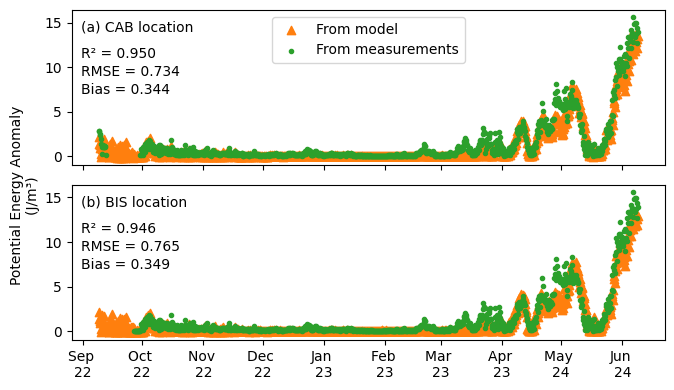

In [82]:
# Plot model x measured for depth
# Plot time series - hourly data
# ax.get_xlim()[0]

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [6.5,4], sharex = True, sharey = True)

pal = sns.color_palette("tab10", 5) # set color range

# CAB location
ax[0].scatter(PEA_CAB_modelled.index, PEA_CAB_modelled['PEA_CAB_modelled'], marker = '^', 
           label = 'From model', color = pal.as_hex()[1])
ax[0].scatter(PEA_CAB_measured_ts.index, PEA_CAB_measured_ts['PEA_CAB_measured'], marker = '.', 
           label = 'From measurements', color = pal.as_hex()[2])

ax[0].text(19235, 11, 'R² = %0.3f' % r2_PEA_CAB, color = 'k', fontsize = 10)
ax[0].text(19235, 9, 'RMSE = %0.3f' % RMSE_PEA_CAB, color = 'k', fontsize = 10)
ax[0].text(19235, 7, 'Bias = %0.3f' % bias_PEA_CAB, color = 'k', fontsize = 10)

ax[0].text(19235, 14, '(a) CAB location', color = 'k', fontsize = 10)

# CAB location
ax[1].scatter(PEA_BIS_modelled.index, PEA_BIS_modelled['PEA_BIS_modelled'], marker = '^', 
           label = 'From model', color = pal.as_hex()[1])
ax[1].scatter(PEA_BIS_measured_ts.index, PEA_BIS_measured_ts['PEA_BIS_measured'], marker = '.', 
           label = 'From measurements', color = pal.as_hex()[2])

ax[1].text(19235, 11, 'R² = %0.3f' % r2_PEA_BIS, color = 'k', fontsize = 10)
ax[1].text(19235, 9, 'RMSE = %0.3f' % RMSE_PEA_BIS, color = 'k', fontsize = 10)
ax[1].text(19235, 7, 'Bias = %0.3f' % bias_PEA_BIS, color = 'k', fontsize = 10)

ax[1].text(19235, 14, '(b) BIS location', color = 'k', fontsize = 10)

# Add legends
ax[0].legend(loc = 'upper center')

# ax.set_ylim(7,10)

# Add formatted date labels
xlabels = ['Sep 22','Oct 22', 'Nov 22', 'Dec 22','Jan 23', 'Feb 23', 'Mar 23','Apr 23', 'May 24', 'Jun 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[1].set_xticklabels(xlabels_new)

# Plot settings
fig.text(-0.03, 0.5, 'Potential Energy Anomaly\n                (J/m³)', va = 'center', rotation = 'vertical')
# fig.subplots_adjust(top = 0.94)

plt.tight_layout()

# Save graph;
# plt.savefig('PEA_model_measured_mdf15_CAB_BIS.jpeg', dpi=300, bbox_inches='tight')

plt.show();


# Histogram

In [83]:
## Creates df with only PEA data to compare
# CAB location
histogram_PEA_CAB = joined_df_PEA_CAB[joined_df_PEA_CAB.columns[[0,1]]]

# BIS location
histogram_PEA_BIS = joined_df_PEA_BIS[joined_df_PEA_BIS.columns[[0,1]]]
histogram_PEA_BIS.head(2)

,PEA_BIS_modelled,PEA_BIS_measured
time,,
2022-09-27 00:00:00,-0.065836,-0.0
2022-09-27 06:00:00,-0.054633,-0.0


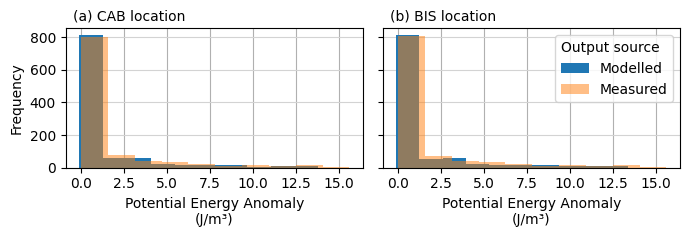

In [84]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = [7,2.5], sharey = True)

# CAB location
histogram_PEA_CAB['PEA_CAB_modelled'].hist(ax = ax[0], label = 'Modelled')
histogram_PEA_CAB['PEA_CAB_measured'].hist(ax = ax[0], label = 'Measured', alpha = 0.5)

ax[0].xaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)
ax[0].yaxis.set_label_text(u'Frequency', fontsize = 10)

ax[0].text(-0.5, 900, '(a) CAB location', color = 'k', fontsize = 10)

ax[0].set_axisbelow(True)
ax[0].grid(color='lightgray', axis = 'y')

# BIS location
histogram_PEA_BIS['PEA_BIS_modelled'].hist(ax = ax[1], label = 'Modelled')
histogram_PEA_BIS['PEA_BIS_measured'].hist(ax = ax[1], label = 'Measured', alpha = 0.5)

ax[1].xaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)

ax[1].text(-0.5, 900, '(b) BIS location', color = 'k', fontsize = 10)

ax[1].legend(title = "Output source", loc="upper right", ncol = 1, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"

ax[1].set_axisbelow(True)
ax[1].grid(color='lightgray', axis = 'y')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('PEA_histogram_CAB_BIS_mdf15.jpeg', dpi = 600, bbox_inches='tight')

plt.show();


# Boxplot

In [85]:
# Creates a single df to plot boxplot with CAB and BIS locations into one plot
## CAB location
joined_df_PEA = joined_df_PEA_CAB[joined_df_PEA_CAB.columns[[0,1,3]]]
joined_df_PEA.rename(columns = {'PEA_CAB_modelled':'Modelled', 
                                'PEA_CAB_measured':'Measured'}, inplace = True)
joined_df_PEA.reset_index(drop = True, inplace = True)
joined_df_PEA['Point ID'] = 'CAB'

# Prepare df with additional column for modelled or measured 
temp = joined_df_PEA[['Modelled', 'month_str','Point ID']]
temp['output'] = temp.columns[0]
temp.rename(columns = {temp.columns[0]:'PEA'}, inplace = True)

PEA_boxplot = temp.copy()

temp_measured = joined_df_PEA[['Measured', 'month_str','Point ID']]
temp_measured['output'] = temp_measured.columns[0]
temp_measured.rename(columns = {temp_measured.columns[0]:'PEA'}, inplace = True)

PEA_boxplot = pd.concat([PEA_boxplot, temp_measured])

## BIS location
joined_PEA_BIS = joined_df_PEA_BIS[joined_df_PEA_BIS.columns[[0,1,3]]]
joined_PEA_BIS.rename(columns = {'PEA_BIS_modelled':'Modelled', 
                                 'PEA_BIS_measured':'Measured'}, inplace = True)
joined_PEA_BIS.reset_index(drop = True, inplace = True)
joined_PEA_BIS['Point ID'] = 'BIS'

# Prepare df with additional column for modelled or measured 
temp_BIS = joined_PEA_BIS[['Modelled', 'month_str','Point ID']]
temp_BIS['output'] = temp_BIS.columns[0]
temp_BIS.rename(columns = {temp_BIS.columns[0]:'PEA'}, inplace = True)

PEA_boxplot_BIS = temp_BIS.copy()

temp_measured_BIS = joined_PEA_BIS[['Measured', 'month_str','Point ID']]
temp_measured_BIS['output'] = temp_measured_BIS.columns[0]
temp_measured_BIS.rename(columns = {temp_measured_BIS.columns[0]:'PEA'}, inplace = True)

PEA_boxplot_BIS = pd.concat([PEA_boxplot_BIS, temp_measured_BIS])

# Concat CAB and BIS locations into one df
pea_boxplot_df = pd.concat([PEA_boxplot, PEA_boxplot_BIS])
pea_boxplot_df.head(2)

,PEA,month_str,Point ID,output
0,2.120779,Sep,CAB,Modelled
1,1.392799,Sep,CAB,Modelled


In [86]:
# Split by location to make seasonal/monthly analysis
pea_boxplot_df_CAB = pea_boxplot_df[pea_boxplot_df['Point ID'] == 'CAB']
pea_boxplot_df_CAB.rename(columns = {'month_str':'Month'}, inplace = True)

pea_boxplot_df_BIS = pea_boxplot_df[pea_boxplot_df['Point ID'] == 'BIS']
pea_boxplot_df_BIS.rename(columns = {'month_str':'Month'}, inplace = True)
# pea_boxplot_df_BIS

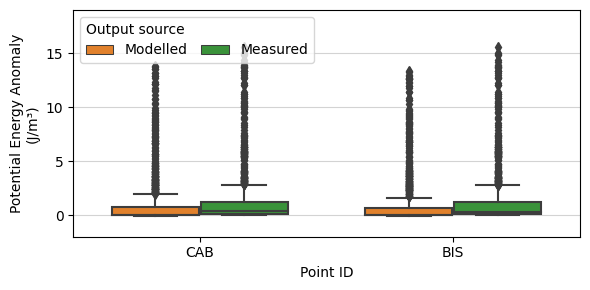

In [87]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6,3])

pal = sns.color_palette("tab10",5)
# depths = joined_df_boxplot['depth'].unique().tolist()

sns.boxplot(x = "Point ID", y = "PEA", 
            data = pea_boxplot_df,
            width = 0.7, boxprops = {'zorder': 1}, 
            palette = pal[1:3], ax = ax, hue = 'output')

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9], depths,
#               fontsize = 10)

ax.set_ylim(-2,19)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
       
ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)

ax.legend(title = "Output source", loc="upper left", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"

# ax.hlines(y = 0, xmin = 0, xmax = 9, color = 'r')
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('PEA_boxplots_CAB_BIS_mdf15.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

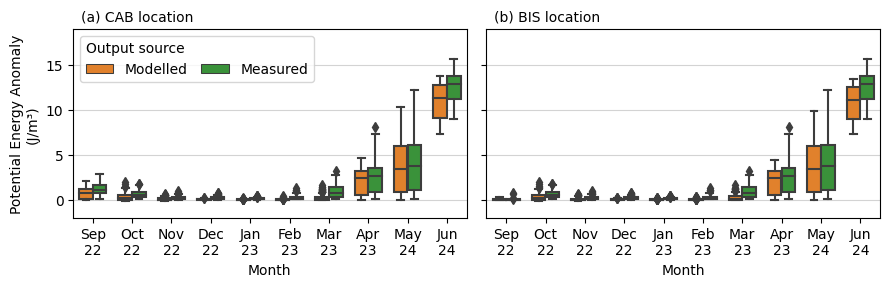

In [88]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = [9,3], sharey = True)

pal = sns.color_palette("tab10",5)

# CAB location
sns.boxplot(x = "Month", y = "PEA", data = pea_boxplot_df_CAB,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax[0], hue = 'output')

ax[0].set_xticks([0,1,2,3,4,5,6,7,8,9],
              ['Sep\n22','Oct\n22', 'Nov\n22', 'Dec\n22','Jan\n23', 'Feb\n23', 'Mar\n23','Apr\n23', 'May\n24', 'Jun\n24'],
              fontsize = 10)

ax[0].set_ylim(-2,19)
ax[0].tick_params(axis = 'y', which = 'major', labelsize = 10)
ax[0].yaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)

ax[0].legend(title = "Output source", loc="upper left", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"
ax[0].set_axisbelow(True)
ax[0].grid(color='lightgray', axis = 'y')

ax[0].text(-0.3, 20, '(a) CAB location', color = 'k', fontsize = 10)

# BIS location
sns.boxplot(x = "Month", y = "PEA", data = pea_boxplot_df_BIS,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax[1], hue = 'output')

ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9],
              ['Sep\n22','Oct\n22', 'Nov\n22', 'Dec\n22','Jan\n23', 'Feb\n23', 'Mar\n23','Apr\n23', 'May\n24', 'Jun\n24'],
              fontsize = 10)

ax[1].set_ylim(-2,19)
ax[1].tick_params(axis = 'y', which = 'major', labelsize = 10)
ax[1].legend_.remove()
ax[1].set_axisbelow(True)
ax[1].yaxis.set_label_text('')
ax[1].grid(color='lightgray', axis = 'y')

ax[1].text(-0.3, 20, '(b) BIS location', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('PEA_monthly_boxplots_CAB_BIS_mdf15.jpeg', dpi = 600, bbox_inches='tight')

plt.show();